# Free-static graph run diagnostics

This notebook audits the completed `free_static_no_entropy` run without changing the model or training configuration. It focuses on whether the BaseDyGraph-style direct graph logits received useful forecasting gradients, moved from initialisation, produced a non-trivial adjacency, and materially affected the forecast representation. It also retains the token and frozen-decoder diagnostics needed before deciding whether to change the coarse/fine objective.

Run the cells in order. Edit paths and diagnostic sample sizes only in **Cell 2**.

In [16]:
# Cell 1 — all imports and repository setup.

from __future__ import annotations

from collections import defaultdict
from pathlib import Path
from typing import Any, Mapping, Sequence

import copy
import json
import math
import os
import random
import sys

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from IPython.display import display
from torch import Tensor, nn

# Locate the repository whether Jupyter was launched from the repository
# root or from notebooks/.
_working_directory = Path.cwd().resolve()
_repository_candidates = [
    _working_directory,
    _working_directory.parent,
    _working_directory.parent.parent,
]

REPO_ROOT = next(
    (
        candidate
        for candidate in _repository_candidates
        if (candidate / "src").is_dir()
        and (candidate / "configs").is_dir()
    ),
    None,
)

if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the dissertation repository root. "
        "Launch Jupyter from the repository root or notebooks/."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.chdir(REPO_ROOT)

from src.data.cached_token_graph_dataset import CachedTokenGraphDataset
from src.data.load_candle_data import (
    clean_candle_splits,
    get_channel_index,
    load_candle_splits,
)
from src.data.token_graph_dataset import (
    load_origin_aligned_token_cache,
    validate_origin_aligned_token_cache,
)
from src.models.dynamic_graph.model import DynamicGraphTokenForecaster
from src.models.dynamic_graph.modules import aggregate_graph_values
from src.models.kronos_tokenizer import KronosTokenizerAdapter
from src.utils.config import load_yaml


In [2]:
# Cell 2 — paths and diagnostic controls.

RUN_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/final_model/initial_test/"
    "free_static_target_entropy"
).expanduser().resolve()

TRAIN_CACHE_PATH = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/final_model/tokens/"
    "origin_aligned_train_tokens.pt"
).expanduser().resolve()

VALIDATION_CACHE_PATH = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/final_model/tokens/"
    "origin_aligned_val_tokens.pt"
).expanduser().resolve()

DATA_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "Shared drives/Vishal/data/cached_datasets/"
    "exp-1m-95s-24y/session"
).expanduser().resolve()

FORECASTING_CONFIG_PATH = REPO_ROOT / "configs" / "forecasting.yaml"

BEST_CHECKPOINT_PATH = RUN_DIR / "best_checkpoint.pt"
LAST_CHECKPOINT_PATH = RUN_DIR / "last_checkpoint.pt"
BEST_PREDICTIONS_PATH = RUN_DIR / "best_validation_predictions.pt"
BEST_GRAPHS_PATH = RUN_DIR / "best_validation_graphs.pt"
HISTORY_PATH = RUN_DIR / "history.csv"
METRIC_TABLE_PATH = RUN_DIR / "best_validation_metric_table.csv"
TOKEN_METRIC_PATH = RUN_DIR / "best_validation_token_metrics.csv"
DIAGNOSTICS_PATH = RUN_DIR / "best_validation_diagnostics.json"
RESOLVED_CONFIG_PATH = RUN_DIR / "resolved_config.json"
RUN_METADATA_PATH = RUN_DIR / "run_metadata.json"

DIAGNOSTIC_SEED = 42
GRADIENT_BATCH_SIZE = 2
TOKEN_DIAGNOSTIC_WINDOWS = 64
TOKEN_DIAGNOSTIC_BATCH_SIZE = 2
DECODE_DIAGNOSTIC_WINDOWS = 6
DECODE_DIAGNOSTIC_ASSETS = 16
TOKENIZER_SERIES_BATCH_SIZE = 64

if torch.cuda.is_available():
    MODEL_DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    MODEL_DEVICE = torch.device("mps")
else:
    MODEL_DEVICE = torch.device("cpu")

required_paths = [
    RUN_DIR,
    TRAIN_CACHE_PATH,
    VALIDATION_CACHE_PATH,
    DATA_DIR,
    FORECASTING_CONFIG_PATH,
    BEST_CHECKPOINT_PATH,
    LAST_CHECKPOINT_PATH,
    BEST_PREDICTIONS_PATH,
    BEST_GRAPHS_PATH,
    HISTORY_PATH,
    METRIC_TABLE_PATH,
    TOKEN_METRIC_PATH,
    DIAGNOSTICS_PATH,
    RESOLVED_CONFIG_PATH,
    RUN_METADATA_PATH,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(path)

print("Repository:", REPO_ROOT)
print("Run directory:", RUN_DIR)
print("Diagnostic device:", MODEL_DEVICE)
print("Token diagnostic windows:", TOKEN_DIAGNOSTIC_WINDOWS)
print(
    "Decoder diagnostic windows/assets:",
    (DECODE_DIAGNOSTIC_WINDOWS, DECODE_DIAGNOSTIC_ASSETS),
)


Repository: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis
Run directory: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/final_model/initial_test/free_static_target_entropy
Diagnostic device: mps
Token diagnostic windows: 64
Decoder diagnostic windows/assets: (6, 16)


In [3]:
# Cell 3 — load artefacts, caches, raw data, and initial/best/last models.

def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)
last_checkpoint = torch.load(
    LAST_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)
prediction_artifact = torch.load(
    BEST_PREDICTIONS_PATH,
    map_location="cpu",
    weights_only=False,
)
graph_artifact = torch.load(
    BEST_GRAPHS_PATH,
    map_location="cpu",
    weights_only=False,
)

history = pd.read_csv(HISTORY_PATH)
metric_table = pd.read_csv(METRIC_TABLE_PATH)
saved_token_metric_table = pd.read_csv(TOKEN_METRIC_PATH)

with DIAGNOSTICS_PATH.open("r", encoding="utf-8") as file:
    saved_diagnostics = json.load(file)

with RESOLVED_CONFIG_PATH.open("r", encoding="utf-8") as file:
    resolved_config_file = json.load(file)

with RUN_METADATA_PATH.open("r", encoding="utf-8") as file:
    run_metadata = json.load(file)

resolved_config = best_checkpoint["resolved_config"]

if resolved_config != resolved_config_file:
    raise AssertionError(
        "best_checkpoint.pt and resolved_config.json disagree."
    )

if last_checkpoint["resolved_config"] != resolved_config:
    raise AssertionError(
        "Best and last checkpoints use different resolved configurations."
    )

model_config = resolved_config["models"]["dynamic_graph"]

if model_config["graph"]["type"] != "free_static":
    raise AssertionError(
        "This notebook requires graph.type='free_static'."
    )

regularisation_config = model_config.get(
    "graph_regularisation",
    {},
)

expected_regularisation = {
    "graph_entropy_reg": 0.0,
    "graph_target_entropy": 2.2,
    "graph_target_entropy_reg": 0.05,
    "graph_temporal_smooth_reg": 0.0,
}

for key, expected_value in expected_regularisation.items():
    observed_value = regularisation_config.get(
        key
    )

    if observed_value is None:
        raise AssertionError(
            f"Missing graph-regularisation setting: {key}"
        )

    if not math.isclose(
        float(observed_value),
        expected_value,
        rel_tol=0.0,
        abs_tol=1.0e-12,
    ):
        raise AssertionError(
            f"Unexpected {key}. "
            f"Expected {expected_value}, "
            f"observed {observed_value}."
        )

prediction_result = prediction_artifact["prediction_result"]
graph_artifacts = graph_artifact["graph_artifacts"]

train_cache = load_origin_aligned_token_cache(TRAIN_CACHE_PATH)
validation_cache = load_origin_aligned_token_cache(VALIDATION_CACHE_PATH)
validate_origin_aligned_token_cache(train_cache)
validate_origin_aligned_token_cache(validation_cache)

train_dataset = CachedTokenGraphDataset(
    train_cache,
    source_path=TRAIN_CACHE_PATH,
    validate=False,
)
validation_dataset = CachedTokenGraphDataset(
    validation_cache,
    source_path=VALIDATION_CACHE_PATH,
    validate=False,
)

train_raw, validation_raw, test_raw = load_candle_splits(DATA_DIR)
train_split, validation_split, _ = clean_candle_splits(
    train_raw,
    validation_raw,
    test_raw,
)

seed = int(resolved_config["training"]["seed"])
set_all_seeds(seed)
initial_model_cpu = DynamicGraphTokenForecaster.from_config(
    resolved_config
).cpu().eval()

best_model_cpu = DynamicGraphTokenForecaster.from_config(
    resolved_config
).cpu()
best_model_cpu.load_state_dict(
    best_checkpoint["model_state_dict"],
    strict=True,
)
best_model_cpu.eval()

last_model_cpu = DynamicGraphTokenForecaster.from_config(
    resolved_config
).cpu()
last_model_cpu.load_state_dict(
    last_checkpoint["model_state_dict"],
    strict=True,
)
last_model_cpu.eval()

forecasting_config = load_yaml(FORECASTING_CONFIG_PATH)
asset_cols = list(validation_cache["asset_cols"])
evaluation_horizons = [
    int(value)
    for value in validation_cache["evaluation_horizons"]
]
evaluation_indices = [
    int(value)
    for value in validation_cache["evaluation_indices"]
]

if asset_cols != list(validation_split["asset_cols"]):
    raise AssertionError(
        "Validation cache and raw split asset ordering differ."
    )

print("Best epoch:", best_checkpoint["epoch"])
print("Last epoch:", last_checkpoint["epoch"])
print("Best primary score:", best_checkpoint["best_score"])
print("Training windows:", len(train_dataset))
print("Validation windows:", len(validation_dataset))
print("Assets:", len(asset_cols))
print("Evaluation horizons:", evaluation_horizons)


Best epoch: 2
Last epoch: 10
Best primary score: 0.0017136413371190429
Training windows: 3173
Validation windows: 380
Assets: 93
Evaluation horizons: [1, 5, 15, 30, 60]


/Users/vishalruparelia/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [4]:
# Cell 4 — shared diagnostic helpers.

def collate_cache_items(
    dataset: CachedTokenGraphDataset,
    indices: Sequence[int],
) -> dict[str, Any]:
    items = [dataset[int(index)] for index in indices]
    output: dict[str, Any] = {}

    for key in items[0]:
        values = [item[key] for item in items]
        if torch.is_tensor(values[0]):
            output[key] = torch.stack(values, dim=0)
        else:
            output[key] = values

    return output


def safe_pearson(
    x: Tensor,
    y: Tensor,
    *,
    eps: float = 1.0e-12,
) -> float:
    x = torch.as_tensor(x).detach().cpu().to(torch.float64).reshape(-1)
    y = torch.as_tensor(y).detach().cpu().to(torch.float64).reshape(-1)
    finite = torch.isfinite(x) & torch.isfinite(y)
    x = x[finite]
    y = y[finite]

    if x.numel() < 2:
        return float("nan")

    x = x - x.mean()
    y = y - y.mean()
    denominator = torch.sqrt(x.square().sum() * y.square().sum())

    if denominator <= eps:
        return float("nan")

    return float((x * y).sum() / denominator)


def off_diagonal_mask(num_nodes: int) -> Tensor:
    return ~torch.eye(num_nodes, dtype=torch.bool)


def graph_statistics(name: str, adjacency: Tensor) -> dict[str, Any]:
    graph = torch.as_tensor(adjacency).detach().cpu().to(torch.float64)

    if graph.ndim != 3 or graph.shape[-1] != graph.shape[-2]:
        raise ValueError("adjacency must have shape [G, N, N].")

    num_nodes = int(graph.shape[-1])
    mask = off_diagonal_mask(num_nodes).unsqueeze(0).expand_as(graph)
    off_diagonal = graph[mask]
    positive = graph > 0

    entropy = -torch.where(
        positive,
        graph * graph.clamp_min(1.0e-12).log(),
        torch.zeros_like(graph),
    ).sum(dim=-1)

    sorted_weights = torch.sort(graph, dim=-1, descending=True).values
    source_mass = graph.sum(dim=1)

    return {
        "state": name,
        "mean_row_entropy": float(entropy.mean()),
        "mean_effective_neighbours": float(entropy.exp().mean()),
        "mean_nonzero_sources": float(
            positive.sum(dim=-1).to(torch.float64).mean()
        ),
        "off_diagonal_weight_mean": float(off_diagonal.mean()),
        "off_diagonal_weight_std": float(off_diagonal.std()),
        "minimum_off_diagonal_weight": float(off_diagonal.min()),
        "maximum_edge_weight": float(graph.max()),
        "mean_top_1_row_mass": float(sorted_weights[..., :1].sum(-1).mean()),
        "mean_top_5_row_mass": float(sorted_weights[..., :5].sum(-1).mean()),
        "mean_top_10_row_mass": float(sorted_weights[..., :10].sum(-1).mean()),
        "mean_top_20_row_mass": float(sorted_weights[..., :20].sum(-1).mean()),
        "source_mass_std": float(source_mass.std()),
        "maximum_source_mass": float(source_mass.max()),
        "head_off_diagonal_correlation": (
            safe_pearson(graph[0][mask[0]], graph[1][mask[1]])
            if int(graph.shape[0]) == 2
            else float("nan")
        ),
    }


def graph_pair_statistics(
    first_name: str,
    first_logits: Tensor,
    first_graph: Tensor,
    second_name: str,
    second_logits: Tensor,
    second_graph: Tensor,
) -> dict[str, Any]:
    first_logits = torch.as_tensor(first_logits).detach().cpu().to(torch.float64)
    second_logits = torch.as_tensor(second_logits).detach().cpu().to(torch.float64)
    first_graph = torch.as_tensor(first_graph).detach().cpu().to(torch.float64)
    second_graph = torch.as_tensor(second_graph).detach().cpu().to(torch.float64)

    num_nodes = int(first_graph.shape[-1])
    mask = off_diagonal_mask(num_nodes).unsqueeze(0).expand_as(first_graph)

    logit_difference = second_logits[mask] - first_logits[mask]
    graph_difference = second_graph[mask] - first_graph[mask]

    return {
        "comparison": f"{first_name} -> {second_name}",
        "off_diagonal_logit_l2_change": float(logit_difference.norm()),
        "off_diagonal_logit_rms_change": float(
            logit_difference.norm() / math.sqrt(logit_difference.numel())
        ),
        "off_diagonal_logit_relative_l2_change": float(
            logit_difference.norm()
            / first_logits[mask].norm().clamp_min(1.0e-12)
        ),
        "maximum_absolute_logit_change": float(logit_difference.abs().max()),
        "adjacency_l2_change": float(graph_difference.norm()),
        "adjacency_rms_change": float(
            graph_difference.norm() / math.sqrt(graph_difference.numel())
        ),
        "maximum_absolute_edge_change": float(graph_difference.abs().max()),
        "adjacency_correlation": safe_pearson(
            first_graph[mask],
            second_graph[mask],
        ),
    }


def module_group(parameter_name: str) -> str:
    if parameter_name.startswith("token_embedding."):
        return "token_embedding"
    if parameter_name.startswith("temporal_blocks."):
        return "temporal_encoder"
    if parameter_name.startswith("graph_learners."):
        return "graph_learner"
    if parameter_name.startswith("spatial_blocks."):
        return "spatial_module"
    if "token_heads.s1_classifier" in parameter_name:
        return "s1_classifier"
    if "token_heads.s2_" in parameter_name:
        return "s2_head"
    if parameter_name.startswith("future_predictor."):
        return "future_predictor_shared"
    return "other"


def select_stratified_windows(
    sample_idx: Tensor,
    *,
    max_windows: int,
    seed: int,
) -> list[int]:
    sample_idx = torch.as_tensor(sample_idx).long()
    generator = np.random.default_rng(seed)
    by_session: dict[int, list[int]] = defaultdict(list)

    for window_index, session_index in enumerate(sample_idx.tolist()):
        by_session[int(session_index)].append(int(window_index))

    for values in by_session.values():
        generator.shuffle(values)

    selected: list[int] = []
    sessions = sorted(by_session)

    while len(selected) < min(max_windows, int(sample_idx.numel())):
        added = False
        for session in sessions:
            values = by_session[session]
            if values:
                selected.append(values.pop())
                added = True
                if len(selected) >= max_windows:
                    break
        if not added:
            break

    return sorted(selected)


def token_ids_to_bits(token_ids: Tensor, *, num_bits: int = 10) -> Tensor:
    bit_positions = torch.arange(
        num_bits,
        device=token_ids.device,
        dtype=torch.long,
    )
    return ((token_ids.long().unsqueeze(-1) >> bit_positions) & 1)


def code_usage_summary(name: str, values: Tensor) -> dict[str, Any]:
    counts = torch.bincount(
        values.long().reshape(-1),
        minlength=1024,
    ).to(torch.float64)
    probabilities = counts[counts > 0]
    probabilities = probabilities / probabilities.sum()
    entropy = float(-(probabilities * probabilities.log()).sum())
    sorted_counts = torch.sort(counts, descending=True).values

    return {
        "stream": name,
        "codes_used": int((counts > 0).sum()),
        "effective_vocabulary": math.exp(entropy),
        "largest_code_share": float(sorted_counts[0] / sorted_counts.sum()),
        "top_10_share": float(sorted_counts[:10].sum() / sorted_counts.sum()),
    }


def invalid_candle_mask(values: Tensor) -> Tensor:
    values = torch.as_tensor(values)
    open_values = values[..., 0]
    high_values = values[..., 1]
    low_values = values[..., 2]
    close_values = values[..., 3]
    volume_values = values[..., 4]

    return (
        ~torch.isfinite(values).all(dim=-1)
        | (open_values <= 0)
        | (high_values <= 0)
        | (low_values <= 0)
        | (close_values <= 0)
        | (high_values < torch.maximum(open_values, close_values))
        | (low_values > torch.minimum(open_values, close_values))
        | (high_values < low_values)
        | (volume_values < 0)
    )


def raw_ohlcv_for_window(
    window_index: int,
    *,
    asset_indices: Sequence[int] | None = None,
) -> tuple[Tensor, Tensor]:
    sample_idx = int(validation_cache["sample_idx"][window_index])
    origin_idx = int(validation_cache["origin_idx"][window_index])
    x_day, _, _ = validation_split["samples"][sample_idx]

    channel_indices = [
        get_channel_index(validation_split, channel)
        for channel in ("open", "high", "low", "close", "volume")
    ]

    if asset_indices is None:
        asset_indices = list(range(len(asset_cols)))

    context_length = int(resolved_config["forecasting"]["context_length"])
    context_start = origin_idx - context_length + 1

    context = x_day[context_start : origin_idx + 1][
        :, asset_indices
    ][..., channel_indices]
    future = x_day[origin_idx + 1 : origin_idx + 61][
        :, asset_indices
    ][..., channel_indices]

    return context.to(torch.float32), future.to(torch.float32)


def evaluate_decoded_variant(
    name: str,
    decoded: Tensor,
    actual: Tensor,
    origin_close: Tensor,
) -> dict[str, Any]:
    decoded = decoded.to(torch.float64)
    actual = actual.to(torch.float64)
    predicted_close = decoded[..., 3].clamp_min(1.0e-8)
    actual_close = actual[..., 3].clamp_min(1.0e-8)
    origin_close = origin_close.to(torch.float64).clamp_min(1.0e-8)

    predicted_eval = predicted_close[:, evaluation_indices]
    actual_eval = actual_close[:, evaluation_indices]
    predicted_clg = torch.log(predicted_eval / origin_close[:, None, :])
    actual_clg = torch.log(actual_eval / origin_close[:, None, :])

    predicted_path = torch.cat([origin_close[:, None, :], predicted_close], dim=1)
    actual_path = torch.cat([origin_close[:, None, :], actual_close], dim=1)
    predicted_returns = torch.log(predicted_path[:, 1:] / predicted_path[:, :-1])
    actual_returns = torch.log(actual_path[:, 1:] / actual_path[:, :-1])

    true_magnitude = actual_clg.abs().mean()
    magnitude_ratio = (
        float(predicted_clg.abs().mean() / true_magnitude)
        if true_magnitude > 0
        else float("nan")
    )

    return {
        "variant": name,
        "dense_log_price_mae": float(
            torch.log(predicted_close / actual_close).abs().mean()
        ),
        "five_horizon_clg_mae": float(
            (predicted_clg - actual_clg).abs().mean()
        ),
        "dense_return_pearson": safe_pearson(
            predicted_returns,
            actual_returns,
        ),
        "movement_magnitude_ratio": magnitude_ratio,
        "invalid_candle_rate_percent": float(
            invalid_candle_mask(decoded).to(torch.float64).mean() * 100.0
        ),
    }


def top_edges_table(
    adjacency: Tensor,
    *,
    edges_per_head: int = 20,
) -> pd.DataFrame:
    graph = torch.as_tensor(adjacency).detach().cpu().to(torch.float64)
    rows: list[dict[str, Any]] = []

    for head in range(int(graph.shape[0])):
        matrix = graph[head].clone()
        matrix.fill_diagonal_(0.0)
        flat_indices = torch.topk(
            matrix.reshape(-1),
            k=min(edges_per_head, matrix.numel()),
        ).indices

        for rank, flat_index in enumerate(flat_indices.tolist(), start=1):
            target = flat_index // int(matrix.shape[1])
            source = flat_index % int(matrix.shape[1])
            rows.append(
                {
                    "head": head,
                    "rank": rank,
                    "target": asset_cols[target],
                    "source": asset_cols[source],
                    "weight": float(matrix[target, source]),
                }
            )

    return pd.DataFrame(rows)


In [5]:
# Cell 5 — artefact alignment and run-integrity audit.

expected_validation_windows = len(validation_dataset)
expected_prediction_shape = (
    expected_validation_windows,
    len(evaluation_horizons),
    len(asset_cols),
    1,
)

if tuple(prediction_result["y_pred"].shape) != expected_prediction_shape:
    raise AssertionError("Unexpected saved prediction shape.")

if tuple(prediction_result["y_true"].shape) != expected_prediction_shape:
    raise AssertionError("Unexpected saved target shape.")

for key in ("sample_idx", "origin_idx"):
    if not torch.equal(prediction_result[key], graph_artifacts[key]):
        raise AssertionError(f"Prediction and graph {key} differ.")
    if not torch.equal(prediction_result[key], validation_cache[key]):
        raise AssertionError(f"Prediction and validation-cache {key} differ.")

sparse_target_indices = validation_cache["target_indices"][:, evaluation_indices]

if not torch.equal(
    prediction_result["target_indices"],
    sparse_target_indices,
):
    raise AssertionError(
        "Saved sparse forecast targets are not aligned with the dense cache."
    )

selected_graphs = torch.as_tensor(graph_artifacts["selected"])
base_graphs = torch.as_tensor(graph_artifacts["base"])
logit_artifacts = torch.as_tensor(graph_artifacts["logits"])

if selected_graphs.shape[0] != expected_validation_windows:
    raise AssertionError("Unexpected graph window dimension.")

if not torch.equal(
    selected_graphs,
    selected_graphs[:1].expand_as(selected_graphs),
):
    raise AssertionError("The free-static graph varies across validation windows.")

if not torch.equal(selected_graphs, base_graphs):
    raise AssertionError("For free_static, selected and base graphs must match.")

best_learner = best_model_cpu.graph_learners[0]
best_checkpoint_logits = best_learner.logits.detach().cpu()
best_checkpoint_graph = best_learner.singleton_adjacency()[0].detach().cpu()

if not torch.allclose(
    logit_artifacts[0],
    best_checkpoint_logits,
    atol=0.0,
    rtol=0.0,
):
    raise AssertionError(
        "Saved graph logits do not match the best checkpoint."
    )

if not torch.allclose(
    selected_graphs[0],
    best_checkpoint_graph,
    atol=1.0e-7,
    rtol=1.0e-6,
):
    raise AssertionError(
        "Saved selected graph does not match the best checkpoint."
    )

primary_from_table = float(
    metric_table.loc[
        metric_table["metric"] == "cumulative_log_change_mae",
        "value",
    ].mean()
)

if not math.isclose(
    primary_from_table,
    float(saved_diagnostics["primary_score"]),
    rel_tol=0.0,
    abs_tol=1.0e-10,
):
    raise AssertionError(
        "Saved primary score does not match the metric table."
    )

integrity_summary = pd.DataFrame(
    [
        {"item": "graph type", "value": graph_artifacts["graph_type"]},
        {"item": "best epoch", "value": best_checkpoint["epoch"]},
        {"item": "last epoch", "value": last_checkpoint["epoch"]},
        {"item": "validation windows", "value": expected_validation_windows},
        {
            "item": "validation sessions",
            "value": int(prediction_result["sample_idx"].unique().numel()),
        },
        {"item": "assets", "value": len(asset_cols)},
        {"item": "primary score", "value": saved_diagnostics["primary_score"]},
        {
            "item": "generated s1 accuracy",
            "value": saved_diagnostics["generated_s1_accuracy"],
        },
        {
            "item": "generated s2 accuracy",
            "value": saved_diagnostics["generated_s2_accuracy"],
        },
        {
            "item": "dense invalid candles (%)",
            "value": saved_diagnostics["invalid_dense_candle_rate_percent"],
        },
    ]
)

display(integrity_summary)
print("FREE-STATIC ARTEFACT ALIGNMENT AUDIT PASSED")


,item,value
0,graph type,free_static
1,best epoch,2
2,last epoch,10
3,validation windows,380
4,validation sessions,20
5,assets,93
6,primary score,0.001714
7,generated s1 accuracy,0.052508
8,generated s2 accuracy,0.05101
9,dense invalid candles (%),35.721326


FREE-STATIC ARTEFACT ALIGNMENT AUDIT PASSED


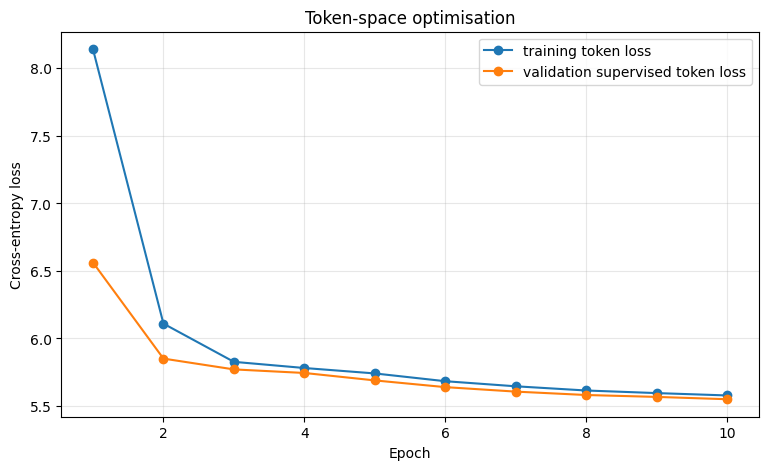

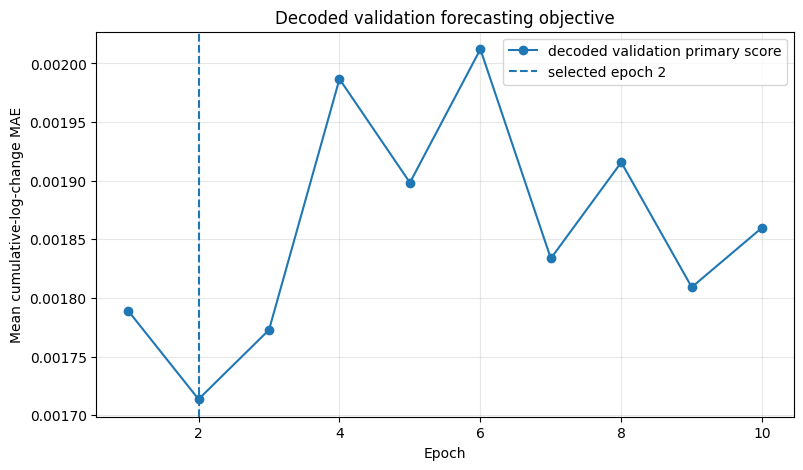

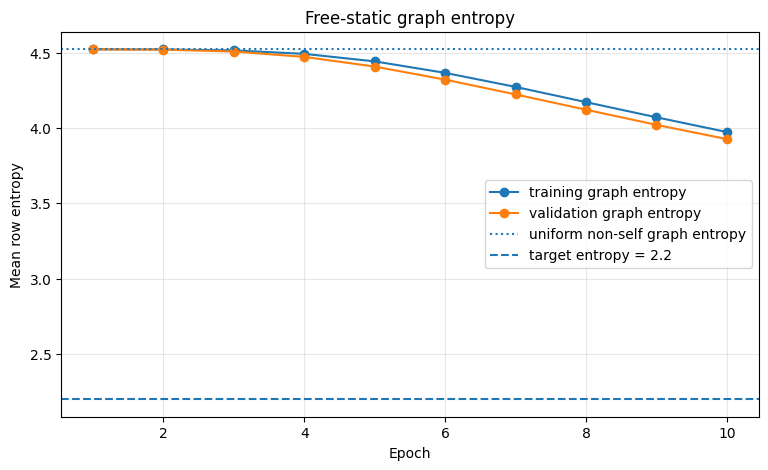

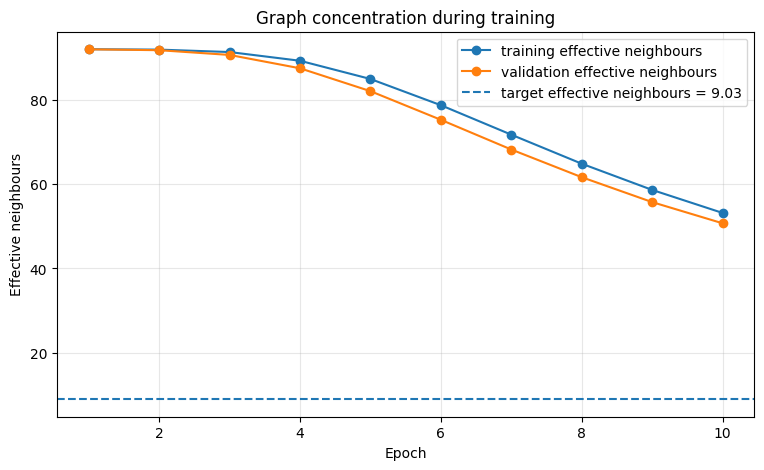

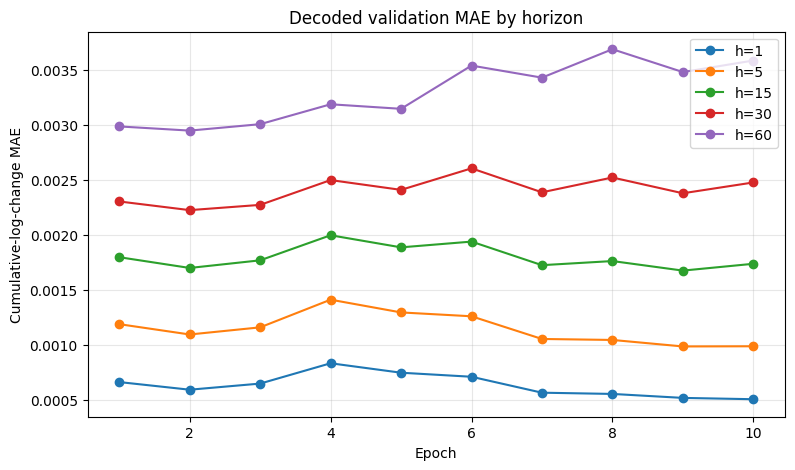

,epoch,train_token_loss,validation_token_loss,primary_score,train_s1_accuracy,train_s2_accuracy,validation_s1_accuracy,validation_s2_accuracy,generated_s1_accuracy,generated_s2_accuracy,train_graph_mean_row_entropy,train_graph_mean_effective_neighbours,train_graph_regularisation_loss,train_graph_target_entropy_penalty
0,1,8.141685,6.562364,0.001789,0.046589,0.354323,0.051508,0.553170,0.051508,0.058429,4.521269,91.952191,0.269414,0.269414
1,2,6.109694,5.850787,0.001714,0.051420,0.571540,0.052508,0.580215,0.052508,0.051010,4.520263,91.859792,0.269181,0.269181
2,10,5.577932,5.549958,0.001860,0.064605,0.587601,0.066151,0.590778,0.066151,0.078530,3.972377,53.153396,0.157103,0.157103


In [6]:
# Cell 6 — training-history diagnostics.

plt.figure(figsize=(9, 5))
plt.plot(
    history["epoch"],
    history["train_token_loss"],
    marker="o",
    label="training token loss",
)
plt.plot(
    history["epoch"],
    history["validation_token_loss"],
    marker="o",
    label="validation supervised token loss",
)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Token-space optimisation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    history["epoch"],
    history["primary_score"],
    marker="o",
    label="decoded validation primary score",
)
plt.axvline(
    int(best_checkpoint["epoch"]),
    linestyle="--",
    label=f"selected epoch {best_checkpoint['epoch']}",
)
plt.xlabel("Epoch")
plt.ylabel("Mean cumulative-log-change MAE")
plt.title("Decoded validation forecasting objective")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    history["epoch"],
    history["train_graph_mean_row_entropy"],
    marker="o",
    label="training graph entropy",
)
plt.plot(
    history["epoch"],
    history["validation_graph_mean_row_entropy"],
    marker="o",
    label="validation graph entropy",
)
plt.axhline(
    math.log(len(asset_cols) - 1),
    linestyle=":",
    label="uniform non-self graph entropy",
)
plt.axhline(
    2.2,
    linestyle="--",
    label="target entropy = 2.2",
)
plt.xlabel("Epoch")
plt.ylabel("Mean row entropy")
plt.title("Free-static graph entropy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    history["epoch"],
    history["train_graph_mean_effective_neighbours"],
    marker="o",
    label="training effective neighbours",
)
plt.plot(
    history["epoch"],
    history["validation_graph_mean_effective_neighbours"],
    marker="o",
    label="validation effective neighbours",
)
plt.axhline(
    math.exp(2.2),
    linestyle="--",
    label=f"target effective neighbours = {math.exp(2.2):.2f}",
)
plt.xlabel("Epoch")
plt.ylabel("Effective neighbours")
plt.title("Graph concentration during training")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
for horizon in evaluation_horizons:
    column = f"val/cumulative_log_change_mae/h{horizon}"
    if column in history:
        plt.plot(
            history["epoch"],
            history[column],
            marker="o",
            label=f"h={horizon}",
        )
plt.xlabel("Epoch")
plt.ylabel("Cumulative-log-change MAE")
plt.title("Decoded validation MAE by horizon")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

selected_history_columns = [
    "epoch",
    "train_token_loss",
    "validation_token_loss",
    "primary_score",
    "train_s1_accuracy",
    "train_s2_accuracy",
    "validation_s1_accuracy",
    "validation_s2_accuracy",
    "generated_s1_accuracy",
    "generated_s2_accuracy",
    "train_graph_mean_row_entropy",
    "train_graph_mean_effective_neighbours",
    "train_graph_regularisation_loss",
    "train_graph_target_entropy_penalty",
]

display(
    history.loc[
        history["epoch"].isin(
            sorted({1, int(best_checkpoint["epoch"]), int(last_checkpoint["epoch"])})
        ),
        [column for column in selected_history_columns if column in history],
    ].reset_index(drop=True)
)


In [7]:
# Cell 7 — initial, best, and last graph states.

def extract_free_static_state(
    model: DynamicGraphTokenForecaster,
) -> tuple[Tensor, Tensor]:
    learner = model.graph_learners[0]

    if not hasattr(learner, "logits") or not hasattr(
        learner, "singleton_adjacency"
    ):
        raise TypeError("Model does not contain a free-static graph learner.")

    logits = learner.logits.detach().cpu().clone()
    adjacency = learner.singleton_adjacency()[0].detach().cpu().clone()
    return logits, adjacency


initial_logits, initial_graph = extract_free_static_state(initial_model_cpu)
best_logits, best_graph = extract_free_static_state(best_model_cpu)
last_logits, last_graph = extract_free_static_state(last_model_cpu)

graph_state_table = pd.DataFrame(
    [
        graph_statistics("initial", initial_graph),
        graph_statistics("best", best_graph),
        graph_statistics("last", last_graph),
    ]
)

graph_movement_table = pd.DataFrame(
    [
        graph_pair_statistics(
            "initial",
            initial_logits,
            initial_graph,
            "best",
            best_logits,
            best_graph,
        ),
        graph_pair_statistics(
            "initial",
            initial_logits,
            initial_graph,
            "last",
            last_logits,
            last_graph,
        ),
        graph_pair_statistics(
            "best",
            best_logits,
            best_graph,
            "last",
            last_logits,
            last_graph,
        ),
    ]
)

# Free-static train/eval graph construction should be exactly deterministic.
dummy_hidden = torch.zeros(
    2,
    int(model_config["context_length"]),
    int(model_config["num_nodes"]),
    int(model_config["d_model"]),
)

best_learner = best_model_cpu.graph_learners[0]
best_learner.train()
train_graph_1 = best_learner(dummy_hidden).selected.detach().cpu()
train_graph_2 = best_learner(dummy_hidden).selected.detach().cpu()
best_learner.eval()
evaluation_graph = best_learner(dummy_hidden).selected.detach().cpu()

if not torch.equal(train_graph_1, train_graph_2):
    raise AssertionError("Free-static training graph is stochastic.")

if not torch.equal(train_graph_1, evaluation_graph):
    raise AssertionError("Free-static train and evaluation graphs differ.")

print("Repeated train/eval graph equality: True")
display(graph_state_table)
display(graph_movement_table)

# Compare parameter movement across the complete model. This contextualises
# the free-static graph movement against the temporal, spatial and future
# predictor modules.
def model_parameter_movement(
    first_model: DynamicGraphTokenForecaster,
    second_model: DynamicGraphTokenForecaster,
    *,
    comparison: str,
) -> pd.DataFrame:
    first_parameters = dict(first_model.named_parameters())
    second_parameters = dict(second_model.named_parameters())
    accumulator: dict[str, dict[str, float]] = defaultdict(
        lambda: {
            "difference_squared": 0.0,
            "first_squared": 0.0,
            "num_parameters": 0.0,
            "maximum_absolute_change": 0.0,
        }
    )

    for parameter_name, second_parameter in second_parameters.items():
        first_parameter = first_parameters[parameter_name]
        difference = (
            second_parameter.detach().to(torch.float64)
            - first_parameter.detach().to(torch.float64)
        )
        group = module_group(parameter_name)
        accumulator[group]["difference_squared"] += float(
            difference.square().sum()
        )
        accumulator[group]["first_squared"] += float(
            first_parameter.detach().to(torch.float64).square().sum()
        )
        accumulator[group]["num_parameters"] += int(second_parameter.numel())
        accumulator[group]["maximum_absolute_change"] = max(
            accumulator[group]["maximum_absolute_change"],
            float(difference.abs().max()),
        )

    rows = []
    for group, values in sorted(accumulator.items()):
        difference_norm = math.sqrt(values["difference_squared"])
        first_norm = math.sqrt(values["first_squared"])
        num_parameters = max(int(values["num_parameters"]), 1)
        rows.append(
            {
                "comparison": comparison,
                "module": group,
                "parameters": num_parameters,
                "absolute_l2_change": difference_norm,
                "relative_l2_change": difference_norm / max(first_norm, 1.0e-12),
                "rms_parameter_change": difference_norm / math.sqrt(num_parameters),
                "maximum_absolute_change": values["maximum_absolute_change"],
            }
        )

    return pd.DataFrame(rows)


parameter_movement_table = pd.concat(
    [
        model_parameter_movement(
            initial_model_cpu,
            best_model_cpu,
            comparison="initial -> best",
        ),
        model_parameter_movement(
            initial_model_cpu,
            last_model_cpu,
            comparison="initial -> last",
        ),
    ],
    ignore_index=True,
)

# Read Adam moments from the best checkpoint. Parameter ordering in an
# optimiser state dict follows model.named_parameters() for this runner.
optimizer_state = best_checkpoint["optimizer_state_dict"]
saved_parameter_ids = [
    parameter_id
    for group in optimizer_state["param_groups"]
    for parameter_id in group["params"]
]
named_parameter_list = list(best_model_cpu.named_parameters())

if len(saved_parameter_ids) != len(named_parameter_list):
    raise AssertionError(
        "Optimizer parameter IDs do not align with model parameters."
    )

optimizer_accumulator: dict[str, dict[str, float]] = defaultdict(
    lambda: {
        "first_moment_squared": 0.0,
        "second_moment_sum": 0.0,
        "num_values": 0.0,
    }
)

for parameter_id, (parameter_name, parameter) in zip(
    saved_parameter_ids,
    named_parameter_list,
    strict=True,
):
    state = optimizer_state["state"].get(parameter_id, {})
    first_moment = state.get("exp_avg")
    second_moment = state.get("exp_avg_sq")

    if first_moment is None:
        continue

    group = module_group(parameter_name)
    optimizer_accumulator[group]["first_moment_squared"] += float(
        first_moment.detach().to(torch.float64).square().sum()
    )
    if second_moment is not None:
        optimizer_accumulator[group]["second_moment_sum"] += float(
            second_moment.detach().to(torch.float64).sum()
        )
    optimizer_accumulator[group]["num_values"] += int(parameter.numel())

optimizer_rows = []
for group, values in sorted(optimizer_accumulator.items()):
    num_values = max(int(values["num_values"]), 1)
    optimizer_rows.append(
        {
            "module": group,
            "adam_first_moment_rms": math.sqrt(
                values["first_moment_squared"] / num_values
            ),
            "adam_second_moment_mean": values["second_moment_sum"] / num_values,
        }
    )

optimizer_moment_table = pd.DataFrame(optimizer_rows)

display(
    parameter_movement_table.sort_values(
        ["comparison", "relative_l2_change"],
        ascending=[True, False],
    )
)
display(
    optimizer_moment_table.sort_values(
        "adam_first_moment_rms",
        ascending=False,
    )
)


Repeated train/eval graph equality: True


,state,mean_row_entropy,mean_effective_neighbours,mean_nonzero_sources,off_diagonal_weight_mean,off_diagonal_weight_std,minimum_off_diagonal_weight,maximum_edge_weight,mean_top_1_row_mass,mean_top_5_row_mass,mean_top_10_row_mass,mean_top_20_row_mass,source_mass_std,maximum_source_mass,head_off_diagonal_correlation
0,initial,4.521586,91.981347,92.0,0.01087,0.000219,0.010030,0.011740,0.011425,0.056568,0.112456,0.223309,0.002067,1.005018,0.005482
1,best,4.518760,91.721773,92.0,0.01087,0.000848,0.008547,0.014201,0.012978,0.063085,0.123739,0.241279,0.012214,1.025306,0.038822
2,last,3.925512,50.700594,92.0,0.01087,0.012568,0.001604,0.045508,0.038695,0.183270,0.350036,0.641347,0.179228,1.417696,0.048147


,comparison,off_diagonal_logit_l2_change,off_diagonal_logit_rms_change,off_diagonal_logit_relative_l2_change,maximum_absolute_logit_change,adjacency_l2_change,adjacency_rms_change,maximum_absolute_edge_change,adjacency_correlation
0,initial -> best,7.672653,0.058654,2.893424,0.191259,0.083787,0.000641,0.002479,0.959886
1,initial -> last,156.993178,1.200136,59.203481,1.580748,1.621281,0.012394,0.033768,0.797138
2,best -> last,150.586995,1.151164,14.801509,1.419452,1.549232,0.011843,0.031594,0.863853


,comparison,module,parameters,absolute_l2_change,relative_l2_change,rms_parameter_change,maximum_absolute_change
1,initial -> best,graph_learner,17298,7.672653,2.878813,0.058337,0.191259
3,initial -> best,s2_head,74944,18.489076,0.890836,0.067538,0.330809
6,initial -> best,token_embedding,140992,6.777827,0.617761,0.018051,0.170861
2,initial -> best,s1_classifier,66560,5.930145,0.318245,0.022986,0.156423
5,initial -> best,temporal_encoder,33472,3.835149,0.217957,0.020962,0.113017
4,initial -> best,spatial_module,25152,2.477354,0.161198,0.015621,0.080586
0,initial -> best,future_predictor_shared,54208,3.015888,0.127796,0.012953,0.116922
8,initial -> last,graph_learner,17298,156.993178,58.904525,1.193666,1.580748
10,initial -> last,s2_head,74944,37.000795,1.782762,0.135158,0.744173
13,initial -> last,token_embedding,140992,12.240203,1.115625,0.032598,0.259990


,module,adam_first_moment_rms,adam_second_moment_mean
3,s2_head,4.313911e-04,1.120340e-05
0,future_predictor_shared,1.301654e-04,1.379278e-06
2,s1_classifier,8.159356e-05,2.886493e-07
4,spatial_module,7.038741e-05,5.821041e-07
6,token_embedding,2.763549e-05,5.905034e-08
5,temporal_encoder,2.239858e-05,4.724515e-08
1,graph_learner,1.415714e-07,7.878088e-14


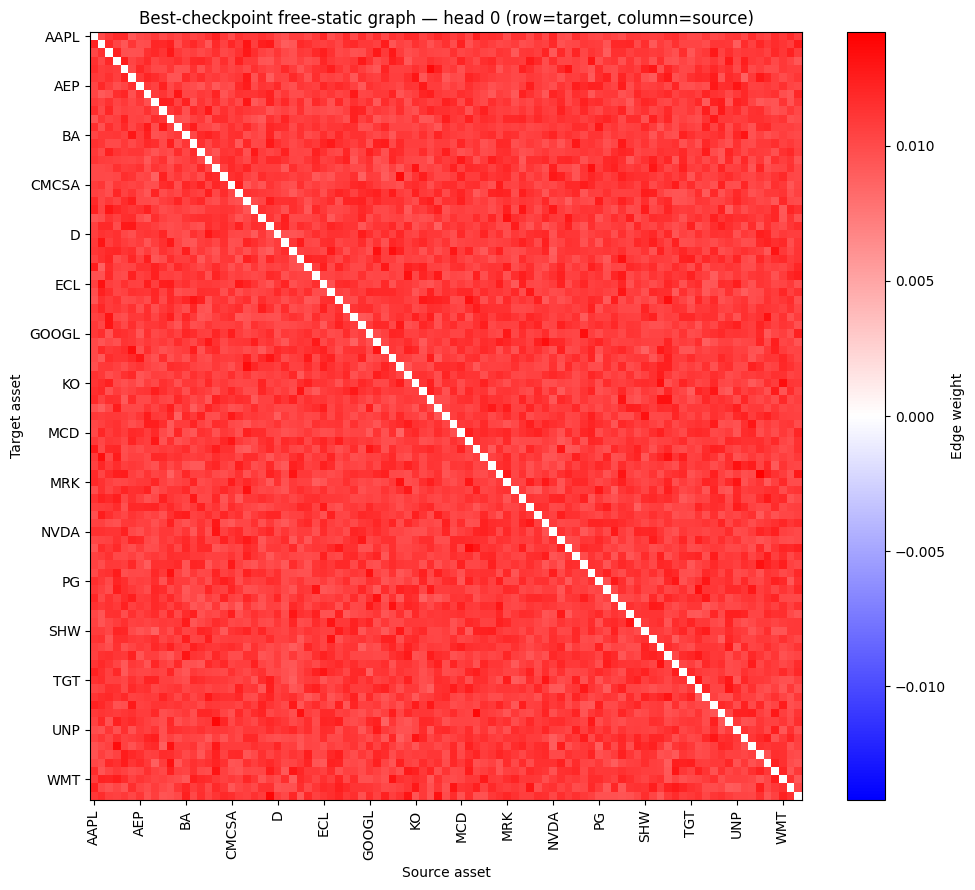

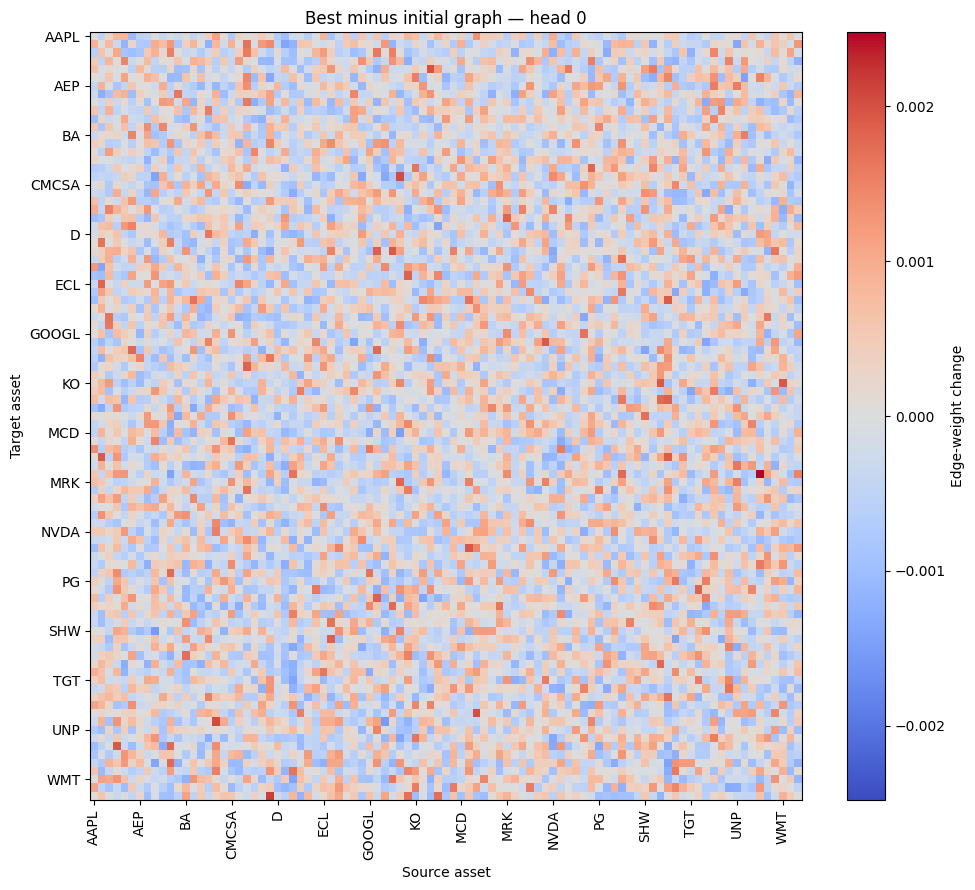

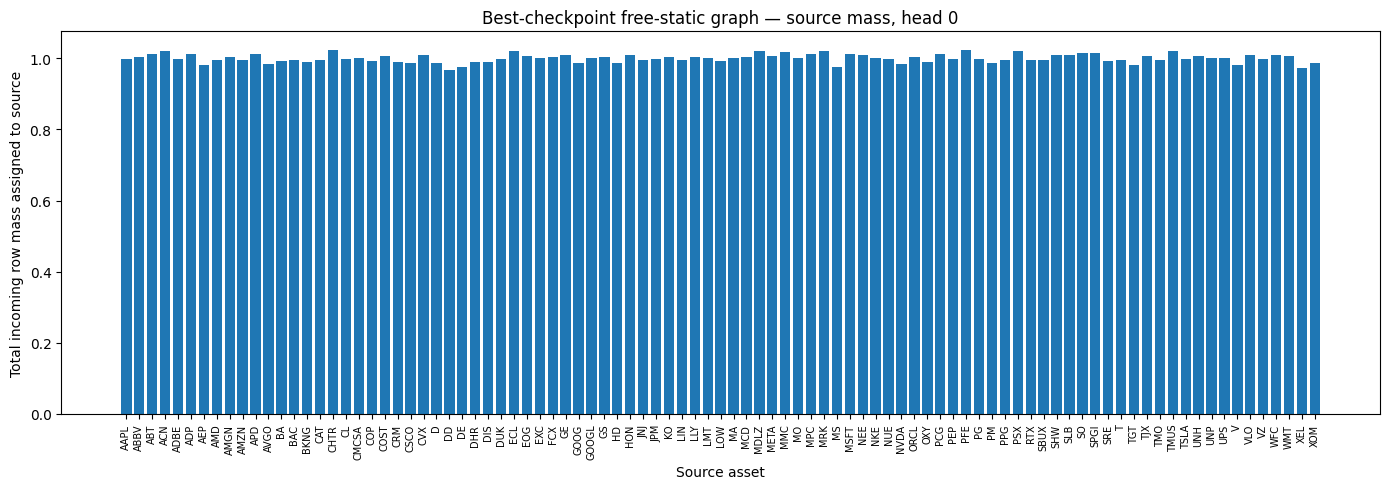

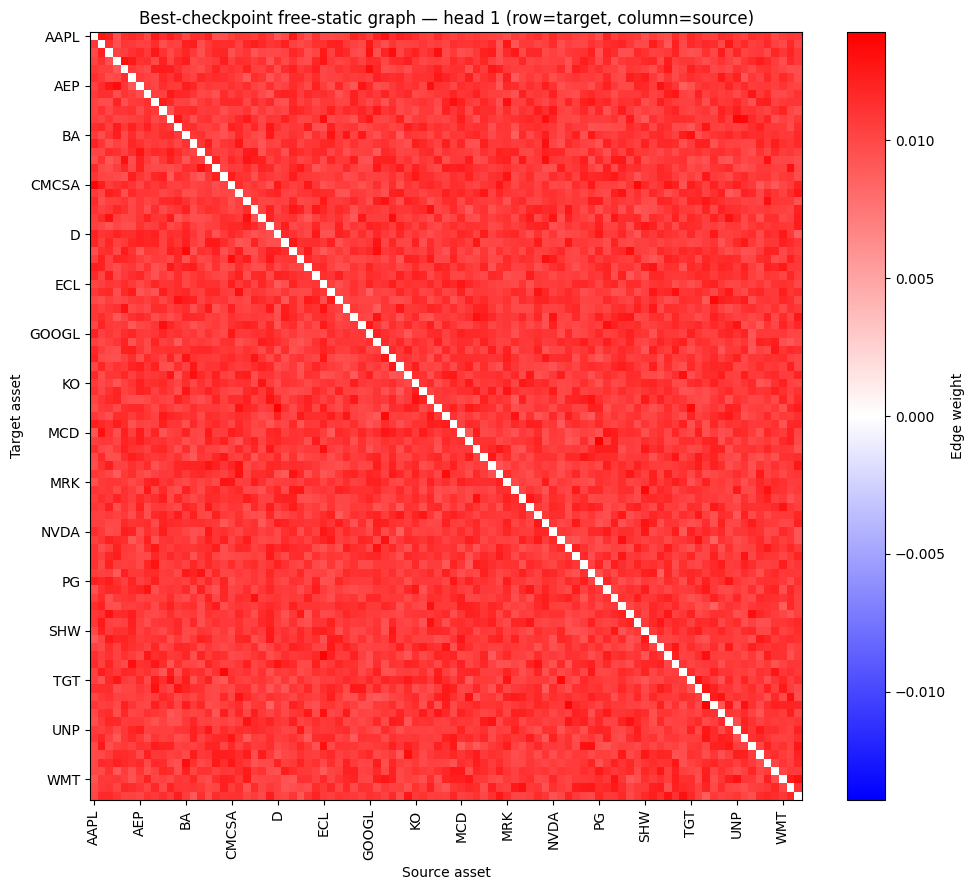

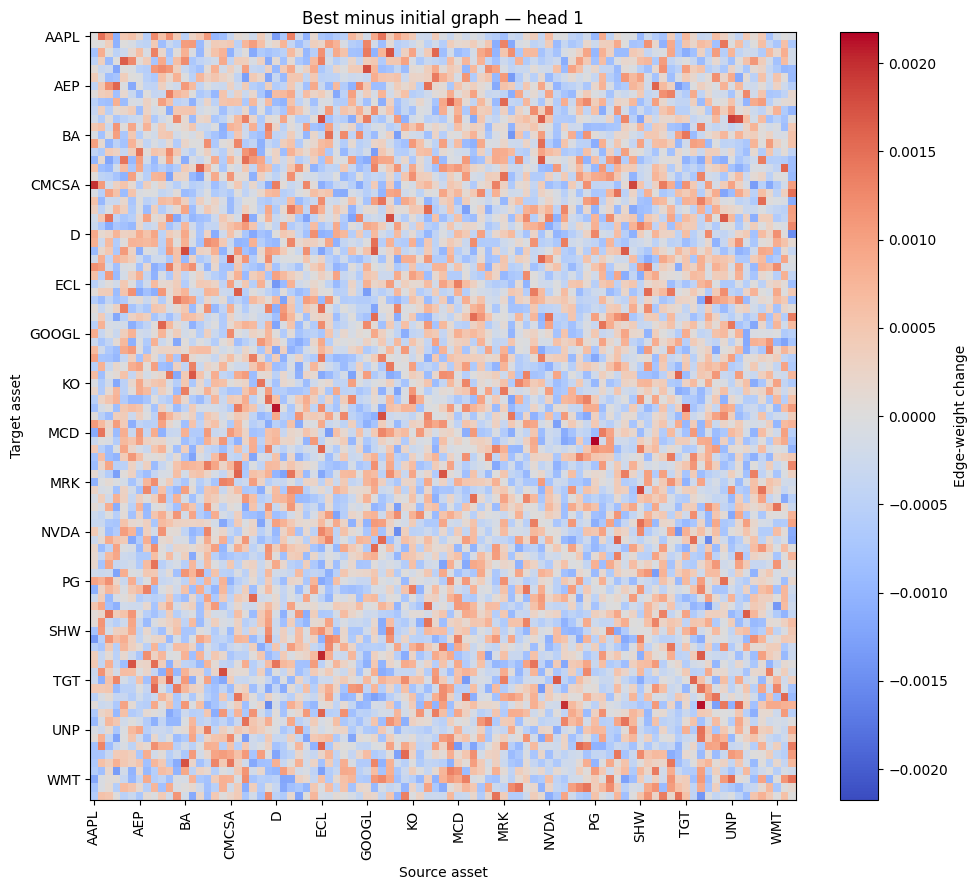

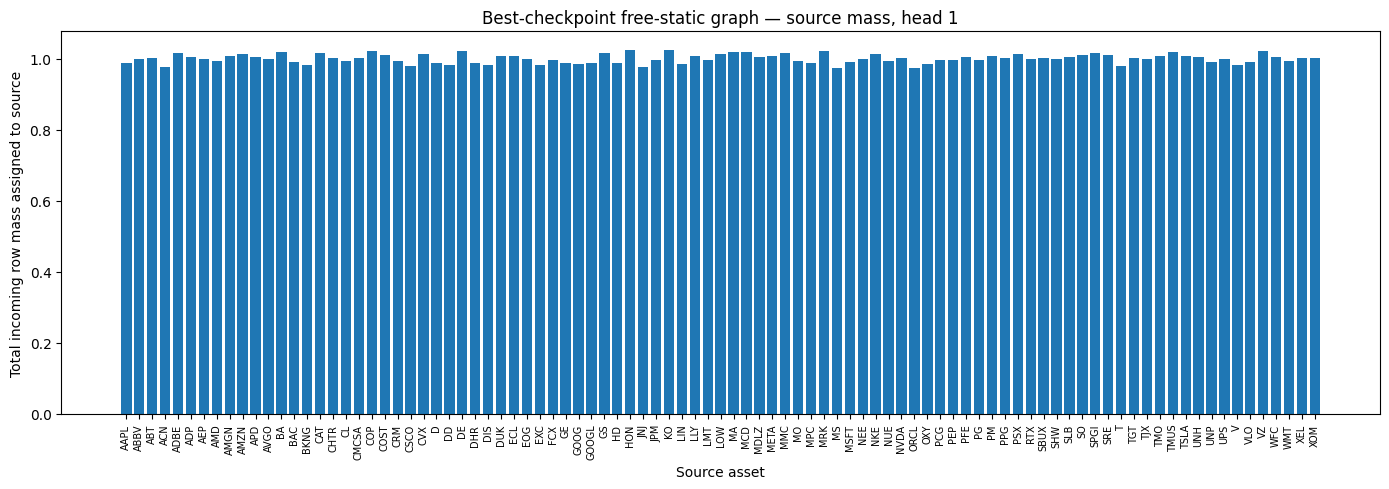

Largest directed edges at the best checkpoint


,head,rank,target,source,weight
0,0,1,MPC,VLO,0.014201
1,0,2,XOM,CVX,0.013784
2,0,3,UNH,CHTR,0.013721
3,0,4,OXY,MDLZ,0.013601
4,0,5,ADBE,LLY,0.013599
5,0,6,CL,JNJ,0.013583
6,0,7,TSLA,META,0.013553
7,0,8,JNJ,COST,0.013444
8,0,9,V,ACN,0.013433
9,0,10,KO,WMT,0.013402


In [17]:
# Cell 8 — graph heat maps, differences, source mass, and top edges.

def plot_graph_heatmap(
    adjacency: Tensor,
    *,
    title: str,
    head: int,
    label_stride: int = 6,
) -> None:
    matrix = adjacency[head].detach().cpu().numpy()
    plt.figure(figsize=(10, 9))
    image = plt.imshow(matrix, aspect="auto", interpolation="nearest",cmap="bwr",norm=mcolors.CenteredNorm())
    plt.colorbar(image, label="Edge weight")
    tick_positions = list(range(0, len(asset_cols), label_stride))
    tick_labels = [asset_cols[position] for position in tick_positions]
    plt.xticks(tick_positions, tick_labels, rotation=90)
    plt.yticks(tick_positions, tick_labels)
    plt.xlabel("Source asset")
    plt.ylabel("Target asset")
    plt.title(f"{title} — head {head} (row=target, column=source)")
    plt.tight_layout()
    plt.show()


def plot_graph_difference(
    first: Tensor,
    second: Tensor,
    *,
    title: str,
    head: int,
    label_stride: int = 6,
) -> None:
    matrix = (second[head] - first[head]).detach().cpu().numpy()
    limit = float(np.max(np.abs(matrix)))
    plt.figure(figsize=(10, 9))
    image = plt.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        vmin=-limit,
        vmax=limit,
        cmap="coolwarm",
    )
    plt.colorbar(image, label="Edge-weight change")
    tick_positions = list(range(0, len(asset_cols), label_stride))
    tick_labels = [asset_cols[position] for position in tick_positions]
    plt.xticks(tick_positions, tick_labels, rotation=90)
    plt.yticks(tick_positions, tick_labels)
    plt.xlabel("Source asset")
    plt.ylabel("Target asset")
    plt.title(f"{title} — head {head}")
    plt.tight_layout()
    plt.show()


def plot_source_mass(adjacency: Tensor, *, title: str, head: int) -> None:
    source_mass = adjacency[head].sum(dim=0).detach().cpu().numpy()
    plt.figure(figsize=(14, 5))
    plt.bar(np.arange(len(asset_cols)), source_mass)
    plt.xticks(
        np.arange(len(asset_cols)),
        asset_cols,
        rotation=90,
        fontsize=7,
    )
    plt.xlabel("Source asset")
    plt.ylabel("Total incoming row mass assigned to source")
    plt.title(f"{title} — source mass, head {head}")
    plt.tight_layout()
    plt.show()


for graph_head in range(int(best_graph.shape[0])):
    plot_graph_heatmap(
        best_graph,
        title="Best-checkpoint free-static graph",
        head=graph_head,
    )
    plot_graph_difference(
        initial_graph,
        best_graph,
        title="Best minus initial graph",
        head=graph_head,
    )
    plot_source_mass(
        best_graph,
        title="Best-checkpoint free-static graph",
        head=graph_head,
    )

print("Largest directed edges at the best checkpoint")
display(top_edges_table(best_graph, edges_per_head=25))


In [9]:
# Cell 9 — forecasting-loss gradients and graph influence on one real batch.

gradient_batch = collate_cache_items(
    train_dataset,
    list(range(GRADIENT_BATCH_SIZE)),
)

context_tokens = gradient_batch["context_tokens"].long()
target_s1 = gradient_batch["target_s1"].long()
target_s2 = gradient_batch["target_s2"].long()

gradient_model = copy.deepcopy(best_model_cpu)
gradient_model.train()

gradient_output = gradient_model(
    context_tokens,
    target_s1=target_s1,
    target_s2=target_s2,
)

s1_loss = F.cross_entropy(
    gradient_output.s1_logits.reshape(-1, gradient_output.s1_logits.shape[-1]),
    target_s1.reshape(-1),
)

if gradient_output.s2_logits is None:
    raise RuntimeError("The full-token run did not return s2 logits.")

s2_loss = F.cross_entropy(
    gradient_output.s2_logits.reshape(-1, gradient_output.s2_logits.shape[-1]),
    target_s2.reshape(-1),
)

named_parameters = [
    (name, parameter)
    for name, parameter in gradient_model.named_parameters()
    if parameter.requires_grad
]
parameters = [parameter for _, parameter in named_parameters]

s1_gradients = torch.autograd.grad(
    s1_loss,
    parameters,
    retain_graph=True,
    allow_unused=True,
)
s2_gradients = torch.autograd.grad(
    s2_loss,
    parameters,
    retain_graph=False,
    allow_unused=True,
)

gradient_accumulator: dict[str, dict[str, float]] = defaultdict(
    lambda: {
        "s1_squared": 0.0,
        "s2_squared": 0.0,
        "dot": 0.0,
        "num_values": 0.0,
    }
)

graph_parameter_diagnostics: dict[str, float] = {}

for (
    (parameter_name, parameter),
    s1_gradient,
    s2_gradient,
) in zip(
    named_parameters,
    s1_gradients,
    s2_gradients,
    strict=True,
):
    group = module_group(parameter_name)
    gradient_accumulator[group]["num_values"] += int(parameter.numel())

    if s1_gradient is not None:
        s1_gradient_64 = s1_gradient.detach().to(torch.float64)
        gradient_accumulator[group]["s1_squared"] += float(
            s1_gradient_64.square().sum()
        )
    else:
        s1_gradient_64 = None

    if s2_gradient is not None:
        s2_gradient_64 = s2_gradient.detach().to(torch.float64)
        gradient_accumulator[group]["s2_squared"] += float(
            s2_gradient_64.square().sum()
        )
    else:
        s2_gradient_64 = None

    if s1_gradient_64 is not None and s2_gradient_64 is not None:
        gradient_accumulator[group]["dot"] += float(
            (s1_gradient_64 * s2_gradient_64).sum()
        )

    if parameter_name == "graph_learners.0.logits":
        mask = (
            off_diagonal_mask(int(parameter.shape[-1]))
            .unsqueeze(0)
            .expand_as(s1_gradient_64)
        )
        if s1_gradient_64 is None or s2_gradient_64 is None:
            raise RuntimeError("Free-static graph logits did not receive gradients.")

        graph_parameter_diagnostics = {
            "s1_off_diagonal_gradient_norm": float(s1_gradient_64[mask].norm()),
            "s1_off_diagonal_gradient_rms": float(
                s1_gradient_64[mask].norm()
                / math.sqrt(s1_gradient_64[mask].numel())
            ),
            "s2_off_diagonal_gradient_norm": float(s2_gradient_64[mask].norm()),
            "s2_off_diagonal_gradient_rms": float(
                s2_gradient_64[mask].norm()
                / math.sqrt(s2_gradient_64[mask].numel())
            ),
            "maximum_absolute_s1_diagonal_gradient": float(
                torch.diagonal(s1_gradient_64, dim1=-2, dim2=-1).abs().max()
            ),
            "maximum_absolute_s2_diagonal_gradient": float(
                torch.diagonal(s2_gradient_64, dim1=-2, dim2=-1).abs().max()
            ),
        }

gradient_rows = []

for group, values in sorted(gradient_accumulator.items()):
    s1_norm = math.sqrt(values["s1_squared"])
    s2_norm = math.sqrt(values["s2_squared"])
    denominator = s1_norm * s2_norm
    num_values = max(int(values["num_values"]), 1)

    gradient_rows.append(
        {
            "module": group,
            "s1_gradient_norm": s1_norm,
            "s2_gradient_norm": s2_norm,
            "s1_gradient_rms": s1_norm / math.sqrt(num_values),
            "s2_gradient_rms": s2_norm / math.sqrt(num_values),
            "s2_to_s1_norm_ratio": s2_norm / max(s1_norm, 1.0e-20),
            "s1_s2_gradient_cosine": (
                values["dot"] / denominator
                if denominator > 0
                else float("nan")
            ),
        }
    )

gradient_table = pd.DataFrame(gradient_rows)
graph_gradient_table = pd.DataFrame([graph_parameter_diagnostics])

# Measure how much the spatial module changes the temporal representation.
spatial_model = copy.deepcopy(best_model_cpu).eval()

with torch.inference_mode():
    embedded = spatial_model.token_embedding(context_tokens)
    pre_spatial = spatial_model.temporal_blocks[0](embedded)
    graph_output = spatial_model.graph_learners[0](pre_spatial)
    adjacency = graph_output.selected

    spatial_layer = spatial_model.spatial_blocks[0].layers[0]
    batch_size, num_steps, num_nodes, hidden_dim = pre_spatial.shape

    values = (
        spatial_layer.value_projection(pre_spatial)
        .view(
            batch_size,
            num_steps,
            num_nodes,
            spatial_layer.num_heads,
            spatial_layer.head_dim,
        )
        .permute(0, 1, 3, 2, 4)
    )

    messages = aggregate_graph_values(adjacency, values)
    messages = (
        messages.permute(0, 1, 3, 2, 4)
        .reshape(batch_size, num_steps, num_nodes, hidden_dim)
    )
    messages = spatial_layer.output_projection(messages)
    post_spatial = spatial_model.spatial_blocks[0](pre_spatial, adjacency)

    # Isolate the effect of learned graph movement by substituting the
    # reconstructed initial graph logits into an otherwise trained model.
    initial_graph_substitution = copy.deepcopy(best_model_cpu).eval()
    initial_graph_substitution.graph_learners[0].logits.copy_(initial_logits)

    best_output = best_model_cpu(
        context_tokens,
        target_s1=target_s1,
        target_s2=target_s2,
    )
    initial_graph_output = initial_graph_substitution(
        context_tokens,
        target_s1=target_s1,
        target_s2=target_s2,
    )

spatial_diagnostics = pd.DataFrame(
    [
        {
            "diagnostic": "s1 scalar loss",
            "value": float(s1_loss),
        },
        {
            "diagnostic": "s2 scalar loss",
            "value": float(s2_loss),
        },
        {
            "diagnostic": "s2 share of s1+s2 scalar loss",
            "value": float(s2_loss / (s1_loss + s2_loss)),
        },
        {
            "diagnostic": "graph-message norm / pre-spatial norm",
            "value": float(
                messages.norm() / pre_spatial.norm().clamp_min(1.0e-12)
            ),
        },
        {
            "diagnostic": "post-spatial change / pre-spatial norm",
            "value": float(
                (post_spatial - pre_spatial).norm()
                / pre_spatial.norm().clamp_min(1.0e-12)
            ),
        },
        {
            "diagnostic": "pre/post-spatial cosine",
            "value": float(
                F.cosine_similarity(
                    pre_spatial.reshape(-1),
                    post_spatial.reshape(-1),
                    dim=0,
                )
            ),
        },
        {
            "diagnostic": "mean |s1 logits(best graph)-s1 logits(initial graph)|",
            "value": float(
                (
                    best_output.s1_logits
                    - initial_graph_output.s1_logits
                ).abs().mean()
            ),
        },
        {
            "diagnostic": "s1 argmax change rate from initial->best graph",
            "value": float(
                (
                    best_output.s1_logits.argmax(dim=-1)
                    != initial_graph_output.s1_logits.argmax(dim=-1)
                ).to(torch.float64).mean()
            ),
        },
    ]
)

display(gradient_table)
display(graph_gradient_table)
display(spatial_diagnostics)

# Retain these for the final summary cell.
free_static_graph_gradient_rms = graph_parameter_diagnostics[
    "s1_off_diagonal_gradient_rms"
]


/var/folders/kg/dmc2syn91z73sggtrcv8x2480000gn/T/ipykernel_74904/2550330079.py:206: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  "value": float(s1_loss),


,module,s1_gradient_norm,s2_gradient_norm,s1_gradient_rms,s2_gradient_rms,s2_to_s1_norm_ratio,s1_s2_gradient_cosine
0,future_predictor_shared,0.483307,2.391622,0.002076,1.027214e-02,4.948457e+00,-0.162602
1,graph_learner,0.000173,0.000092,0.000001,7.026787e-07,5.337620e-01,0.078215
2,s1_classifier,1.179666,0.000000,0.004572,0.000000e+00,0.000000e+00,NaN
3,s2_head,0.000000,8.812714,0.000000,3.219150e-02,8.812714e+20,NaN
4,spatial_module,0.303669,0.826293,0.001915,5.210122e-03,2.721032e+00,-0.057688
5,temporal_encoder,0.136649,0.103804,0.000747,5.673769e-04,7.596361e-01,0.081564
6,token_embedding,0.288219,0.244375,0.000768,6.508173e-04,8.478780e-01,0.055474


,s1_off_diagonal_gradient_norm,s1_off_diagonal_gradient_rms,s2_off_diagonal_gradient_norm,s2_off_diagonal_gradient_rms,maximum_absolute_s1_diagonal_gradient,maximum_absolute_s2_diagonal_gradient
0,0.000173,0.000001,0.000092,7.064872e-07,0.0,0.0


,diagnostic,value
0,s1 scalar loss,4.384254
1,s2 scalar loss,1.039954
2,s2 share of s1+s2 scalar loss,0.191725
3,graph-message norm / pre-spatial norm,1.468288
4,post-spatial change / pre-spatial norm,0.777725
5,pre/post-spatial cosine,0.825545
6,mean |s1 logits(best graph)-s1 logits(initial ...,0.000141
7,s1 argmax change rate from initial->best graph,0.000358


,future_step,is_evaluation_horizon,s1_ce,s2_ce_with_true_s1,s2_ce_with_predicted_s1,s1_top1,s1_top5,s1_top10,s2_top1_with_true_s1,s2_top1_with_predicted_s1,joint_pair_top1,s1_bit_accuracy,s2_bit_accuracy,s1_predictive_entropy,s2_predictive_entropy,training_marginal_s1_mode_accuracy,training_marginal_s2_mode_accuracy
0,1,True,4.427498,1.144541,4.684874,0.097950,0.262433,0.399530,0.568884,0.124160,0.040659,0.694036,0.741818,4.721582,1.723430,0.057460,0.139617
1,5,True,4.564729,1.095927,5.225815,0.076613,0.215558,0.329469,0.587030,0.081989,0.027050,0.652638,0.693918,4.721084,1.723533,0.045195,0.143649
2,15,True,4.734228,1.143364,5.768252,0.052419,0.176243,0.287466,0.566196,0.063844,0.019489,0.607056,0.650134,4.720676,1.724311,0.035618,0.113911
3,30,True,4.824114,1.145487,6.138537,0.044859,0.165323,0.268145,0.585853,0.042171,0.016129,0.589567,0.617221,4.719834,1.730912,0.031418,0.120632
4,60,True,4.923499,1.134982,6.515750,0.039819,0.148017,0.244960,0.587030,0.030746,0.011593,0.583149,0.590390,4.720616,1.731109,0.035450,0.093918


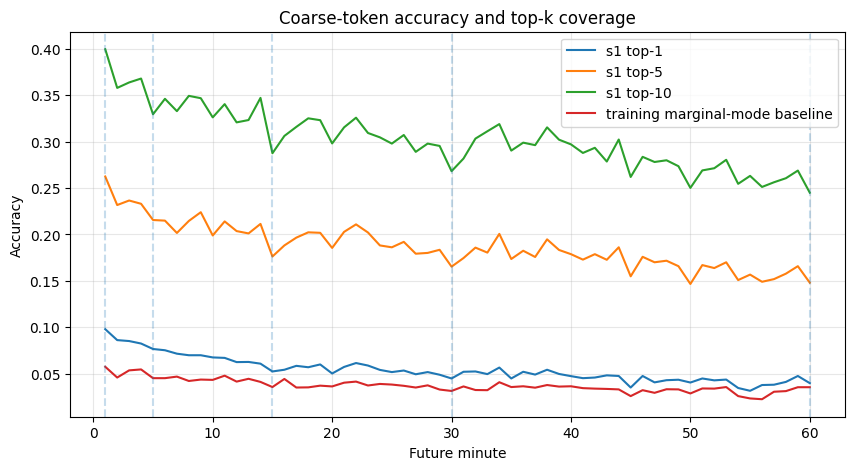

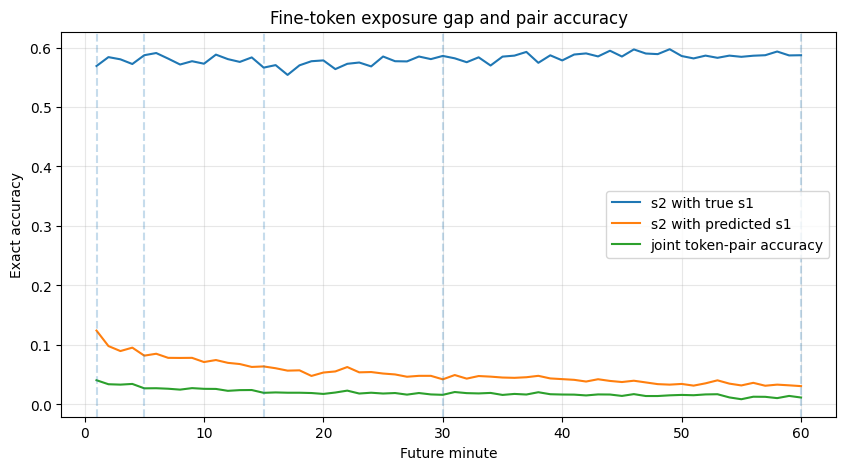

,stream,codes_used,effective_vocabulary,largest_code_share,top_10_share
0,true s1,565,130.460180,0.037629,0.242042
1,generated s1,4,2.672233,0.535417,1.000000
2,true s2,316,40.045753,0.117431,0.572457
3,generated s2,8,3.804463,0.522404,1.000000


,condition,positions,generated_s2_accuracy
0,all positions,357120,0.053049
1,generated s1 correct,19326,0.360861
2,generated s1 wrong,337794,0.035439


In [10]:
# Cell 10 — validation token diagnostics on windows spread across sessions.

token_diagnostic_indices = select_stratified_windows(
    validation_cache["sample_idx"],
    max_windows=TOKEN_DIAGNOSTIC_WINDOWS,
    seed=DIAGNOSTIC_SEED,
)

diagnostic_model = copy.deepcopy(best_model_cpu).to(MODEL_DEVICE).eval()
num_future_steps = int(model_config["heads"]["prediction_length"])

metric_sums = {
    name: torch.zeros(num_future_steps, dtype=torch.float64)
    for name in (
        "count",
        "s1_ce",
        "s2_ce_true_s1",
        "s2_ce_predicted_s1",
        "s1_top1",
        "s1_top5",
        "s1_top10",
        "s2_true_s1_top1",
        "s2_predicted_s1_top1",
        "joint_pair_top1",
        "s1_bit_accuracy",
        "s2_bit_accuracy",
        "s1_predictive_entropy",
        "s2_predictive_entropy",
    )
}

stored_context_tokens = []
stored_true_s1 = []
stored_true_s2 = []
stored_generated_s1 = []
stored_generated_s2 = []
stored_teacher_s2 = []

with torch.inference_mode():
    for start in range(
        0,
        len(token_diagnostic_indices),
        TOKEN_DIAGNOSTIC_BATCH_SIZE,
    ):
        stop = min(
            start + TOKEN_DIAGNOSTIC_BATCH_SIZE,
            len(token_diagnostic_indices),
        )
        batch_indices = token_diagnostic_indices[start:stop]
        batch = collate_cache_items(validation_dataset, batch_indices)

        context = batch["context_tokens"].to(MODEL_DEVICE)
        true_s1 = batch["target_s1"].to(MODEL_DEVICE)
        true_s2 = batch["target_s2"].to(MODEL_DEVICE)

        teacher_output = diagnostic_model(
            context,
            target_s1=true_s1,
            target_s2=true_s2,
        )
        generated = diagnostic_model.generate(context)

        s1_logits = teacher_output.s1_logits
        s2_true_s1_logits = teacher_output.s2_logits
        s2_predicted_s1_logits = generated.forecast.s2_logits

        if s2_true_s1_logits is None or s2_predicted_s1_logits is None:
            raise RuntimeError("Full-token diagnostics require s2 logits.")

        generated_s1 = generated.token_ids[..., 0]
        generated_s2 = generated.token_ids[..., 1]
        teacher_s2 = s2_true_s1_logits.argmax(dim=-1)
        batch_count = int(context.shape[0]) * int(context.shape[2])
        metric_sums["count"] += batch_count

        s1_ce = F.cross_entropy(
            s1_logits.reshape(-1, s1_logits.shape[-1]),
            true_s1.reshape(-1),
            reduction="none",
        ).reshape_as(true_s1)
        s2_true_ce = F.cross_entropy(
            s2_true_s1_logits.reshape(-1, s2_true_s1_logits.shape[-1]),
            true_s2.reshape(-1),
            reduction="none",
        ).reshape_as(true_s2)
        s2_predicted_ce = F.cross_entropy(
            s2_predicted_s1_logits.reshape(
                -1, s2_predicted_s1_logits.shape[-1]
            ),
            true_s2.reshape(-1),
            reduction="none",
        ).reshape_as(true_s2)

        metric_sums["s1_ce"] += s1_ce.sum(dim=(0, 2)).cpu().to(torch.float64)
        metric_sums["s2_ce_true_s1"] += (
            s2_true_ce.sum(dim=(0, 2)).cpu().to(torch.float64)
        )
        metric_sums["s2_ce_predicted_s1"] += (
            s2_predicted_ce.sum(dim=(0, 2)).cpu().to(torch.float64)
        )

        for top_k_value in (1, 5, 10):
            predictions = torch.topk(
                s1_logits,
                k=top_k_value,
                dim=-1,
            ).indices
            correct = (predictions == true_s1.unsqueeze(-1)).any(dim=-1)
            metric_sums[f"s1_top{top_k_value}"] += (
                correct.sum(dim=(0, 2)).cpu().to(torch.float64)
            )

        metric_sums["s2_true_s1_top1"] += (
            (teacher_s2 == true_s2).sum(dim=(0, 2)).cpu().to(torch.float64)
        )
        metric_sums["s2_predicted_s1_top1"] += (
            (generated_s2 == true_s2).sum(dim=(0, 2)).cpu().to(torch.float64)
        )
        metric_sums["joint_pair_top1"] += (
            ((generated_s1 == true_s1) & (generated_s2 == true_s2))
            .sum(dim=(0, 2))
            .cpu()
            .to(torch.float64)
        )

        s1_bit_accuracy = (
            token_ids_to_bits(generated_s1) == token_ids_to_bits(true_s1)
        ).to(torch.float32).mean(dim=-1)
        s2_bit_accuracy = (
            token_ids_to_bits(generated_s2) == token_ids_to_bits(true_s2)
        ).to(torch.float32).mean(dim=-1)
        metric_sums["s1_bit_accuracy"] += s1_bit_accuracy.sum(dim=(0, 2)).cpu()
        metric_sums["s2_bit_accuracy"] += s2_bit_accuracy.sum(dim=(0, 2)).cpu()

        s1_log_probabilities = F.log_softmax(s1_logits, dim=-1)
        s1_probabilities = s1_log_probabilities.exp()
        s1_entropy = -(s1_probabilities * s1_log_probabilities).sum(dim=-1)

        s2_log_probabilities = F.log_softmax(s2_predicted_s1_logits, dim=-1)
        s2_probabilities = s2_log_probabilities.exp()
        s2_entropy = -(s2_probabilities * s2_log_probabilities).sum(dim=-1)

        metric_sums["s1_predictive_entropy"] += (
            s1_entropy.sum(dim=(0, 2)).cpu().to(torch.float64)
        )
        metric_sums["s2_predictive_entropy"] += (
            s2_entropy.sum(dim=(0, 2)).cpu().to(torch.float64)
        )

        stored_context_tokens.append(context.detach().cpu().to(torch.int16))
        stored_true_s1.append(true_s1.detach().cpu().to(torch.int16))
        stored_true_s2.append(true_s2.detach().cpu().to(torch.int16))
        stored_generated_s1.append(
            generated_s1.detach().cpu().to(torch.int16)
        )
        stored_generated_s2.append(
            generated_s2.detach().cpu().to(torch.int16)
        )
        stored_teacher_s2.append(teacher_s2.detach().cpu().to(torch.int16))


token_diagnostics = {
    "window_indices": torch.tensor(token_diagnostic_indices, dtype=torch.long),
    "context_tokens": torch.cat(stored_context_tokens, dim=0),
    "true_s1": torch.cat(stored_true_s1, dim=0),
    "true_s2": torch.cat(stored_true_s2, dim=0),
    "generated_s1": torch.cat(stored_generated_s1, dim=0),
    "generated_s2": torch.cat(stored_generated_s2, dim=0),
    "teacher_s2": torch.cat(stored_teacher_s2, dim=0),
}

counts = metric_sums["count"].clamp_min(1.0)
train_target_s1 = train_cache["target_s1"].long()
train_target_s2 = train_cache["target_s2"].long()
true_s1_subset = token_diagnostics["true_s1"].long()
true_s2_subset = token_diagnostics["true_s2"].long()

per_step_rows = []

for step in range(num_future_steps):
    training_s1_counts = torch.bincount(
        train_target_s1[:, step].reshape(-1),
        minlength=1024,
    ).to(torch.float64)
    training_s2_counts = torch.bincount(
        train_target_s2[:, step].reshape(-1),
        minlength=1024,
    ).to(torch.float64)
    marginal_s1_mode = int(training_s1_counts.argmax())
    marginal_s2_mode = int(training_s2_counts.argmax())

    per_step_rows.append(
        {
            "future_step": step + 1,
            "is_evaluation_horizon": step + 1 in evaluation_horizons,
            "s1_ce": float(metric_sums["s1_ce"][step] / counts[step]),
            "s2_ce_with_true_s1": float(
                metric_sums["s2_ce_true_s1"][step] / counts[step]
            ),
            "s2_ce_with_predicted_s1": float(
                metric_sums["s2_ce_predicted_s1"][step] / counts[step]
            ),
            "s1_top1": float(metric_sums["s1_top1"][step] / counts[step]),
            "s1_top5": float(metric_sums["s1_top5"][step] / counts[step]),
            "s1_top10": float(metric_sums["s1_top10"][step] / counts[step]),
            "s2_top1_with_true_s1": float(
                metric_sums["s2_true_s1_top1"][step] / counts[step]
            ),
            "s2_top1_with_predicted_s1": float(
                metric_sums["s2_predicted_s1_top1"][step] / counts[step]
            ),
            "joint_pair_top1": float(
                metric_sums["joint_pair_top1"][step] / counts[step]
            ),
            "s1_bit_accuracy": float(
                metric_sums["s1_bit_accuracy"][step] / counts[step]
            ),
            "s2_bit_accuracy": float(
                metric_sums["s2_bit_accuracy"][step] / counts[step]
            ),
            "s1_predictive_entropy": float(
                metric_sums["s1_predictive_entropy"][step] / counts[step]
            ),
            "s2_predictive_entropy": float(
                metric_sums["s2_predictive_entropy"][step] / counts[step]
            ),
            "training_marginal_s1_mode_accuracy": float(
                (true_s1_subset[:, step] == marginal_s1_mode)
                .to(torch.float64)
                .mean()
            ),
            "training_marginal_s2_mode_accuracy": float(
                (true_s2_subset[:, step] == marginal_s2_mode)
                .to(torch.float64)
                .mean()
            ),
        }
    )

token_step_table = pd.DataFrame(per_step_rows)

display(
    token_step_table.loc[
        token_step_table["is_evaluation_horizon"]
    ].reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
plt.plot(token_step_table["future_step"], token_step_table["s1_top1"], label="s1 top-1")
plt.plot(token_step_table["future_step"], token_step_table["s1_top5"], label="s1 top-5")
plt.plot(token_step_table["future_step"], token_step_table["s1_top10"], label="s1 top-10")
plt.plot(
    token_step_table["future_step"],
    token_step_table["training_marginal_s1_mode_accuracy"],
    label="training marginal-mode baseline",
)
for horizon in evaluation_horizons:
    plt.axvline(horizon, linestyle="--", alpha=0.25)
plt.xlabel("Future minute")
plt.ylabel("Accuracy")
plt.title("Coarse-token accuracy and top-k coverage")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    token_step_table["future_step"],
    token_step_table["s2_top1_with_true_s1"],
    label="s2 with true s1",
)
plt.plot(
    token_step_table["future_step"],
    token_step_table["s2_top1_with_predicted_s1"],
    label="s2 with predicted s1",
)
plt.plot(
    token_step_table["future_step"],
    token_step_table["joint_pair_top1"],
    label="joint token-pair accuracy",
)
for horizon in evaluation_horizons:
    plt.axvline(horizon, linestyle="--", alpha=0.25)
plt.xlabel("Future minute")
plt.ylabel("Exact accuracy")
plt.title("Fine-token exposure gap and pair accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

code_usage_table = pd.DataFrame(
    [
        code_usage_summary("true s1", token_diagnostics["true_s1"]),
        code_usage_summary("generated s1", token_diagnostics["generated_s1"]),
        code_usage_summary("true s2", token_diagnostics["true_s2"]),
        code_usage_summary("generated s2", token_diagnostics["generated_s2"]),
    ]
)

display(code_usage_table)

s1_correct = token_diagnostics["generated_s1"] == token_diagnostics["true_s1"]
s2_correct = token_diagnostics["generated_s2"] == token_diagnostics["true_s2"]

conditional_s2_table = pd.DataFrame(
    [
        {
            "condition": "all positions",
            "positions": int(s2_correct.numel()),
            "generated_s2_accuracy": float(s2_correct.to(torch.float64).mean()),
        },
        {
            "condition": "generated s1 correct",
            "positions": int(s1_correct.sum()),
            "generated_s2_accuracy": float(
                s2_correct[s1_correct].to(torch.float64).mean()
            ),
        },
        {
            "condition": "generated s1 wrong",
            "positions": int((~s1_correct).sum()),
            "generated_s2_accuracy": float(
                s2_correct[~s1_correct].to(torch.float64).mean()
            ),
        },
    ]
)

display(conditional_s2_table)


,future_step,is_evaluation_horizon,mean_true_token_probability,mean_selected_token_probability,mean_probability_gap,mean_true_to_selected_ratio,mean_top1_top2_margin,mean_top5_probability_mass,mean_top10_probability_mass,argmax_exact_accuracy,expected_single_sample_exact_accuracy,mean_true_rank
0,1,True,0.018803,0.050506,0.031703,0.370533,0.012344,0.176355,0.288160,0.097950,0.018803,33.905074
1,5,True,0.016789,0.050600,0.033811,0.330599,0.012328,0.176720,0.288359,0.076613,0.016789,38.230175
2,15,True,0.015017,0.050560,0.035543,0.295844,0.012181,0.177022,0.288661,0.052419,0.015017,44.720598
3,30,True,0.014316,0.050436,0.036119,0.282695,0.012035,0.177491,0.288962,0.044859,0.014316,48.648017
4,60,True,0.013385,0.050194,0.036809,0.265391,0.012063,0.177085,0.288783,0.039819,0.013385,51.962870


,condition,positions,share_of_positions,mean_true_token_probability,mean_selected_token_probability,mean_probability_gap,mean_true_to_selected_ratio,mean_top1_top2_margin,mean_true_rank
0,all positions,357120,1.000000,0.015471,0.050559,0.035087,0.304975,0.012249,42.720733
1,argmax correct,19326,0.054116,0.051651,0.051651,0.000000,1.000000,0.012810,1.000000
2,argmax wrong,337794,0.945884,0.013401,0.050496,0.037095,0.265211,0.012216,45.107675
3,true rank 2–5,47400,0.132728,0.033374,0.051009,0.017635,0.654519,0.011542,3.358080
4,true rank 6–10,41252,0.115513,0.023046,0.050834,0.027788,0.453453,0.011913,7.853680
5,true rank >10,249142,0.697642,0.008004,0.050342,0.042338,0.159976,0.012395,59.219036


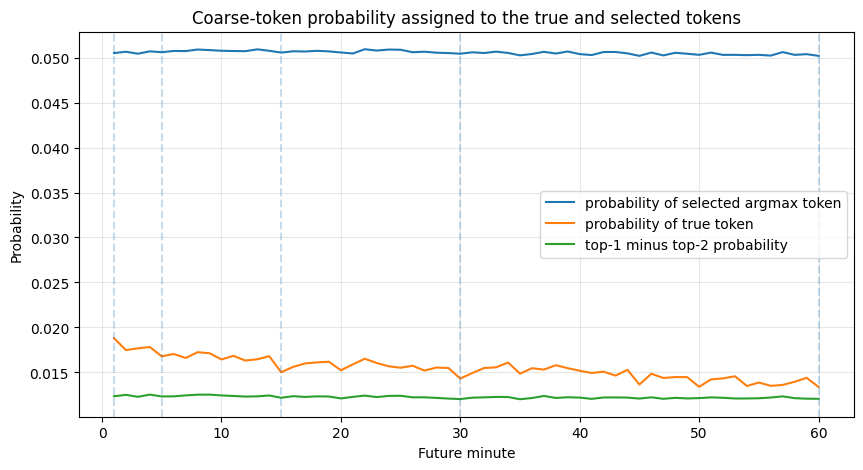

In [18]:
# Cell 10A — probability assigned to the true versus selected s1 token.

# This uses the model's unmodified softmax distribution.
# A later sampling ablation can separately test other temperatures.
PROBABILITY_TEMPERATURE = 1.0

probability_sums = {
    name: torch.zeros(
        num_future_steps,
        dtype=torch.float64,
    )
    for name in (
        "count",
        "true_probability",
        "selected_probability",
        "probability_gap",
        "true_to_selected_ratio",
        "top1_top2_margin",
        "top5_probability_mass",
        "top10_probability_mass",
        "argmax_correct",
        "true_rank",
    )
}

flat_true_probabilities = []
flat_selected_probabilities = []
flat_probability_gaps = []
flat_probability_ratios = []
flat_top1_top2_margins = []
flat_true_ranks = []
flat_argmax_correct = []

with torch.inference_mode():
    for start in range(
        0,
        len(token_diagnostic_indices),
        TOKEN_DIAGNOSTIC_BATCH_SIZE,
    ):
        stop = min(
            start + TOKEN_DIAGNOSTIC_BATCH_SIZE,
            len(token_diagnostic_indices),
        )

        batch_indices = token_diagnostic_indices[
            start:stop
        ]

        batch = collate_cache_items(
            validation_dataset,
            batch_indices,
        )

        context = batch[
            "context_tokens"
        ].to(
            MODEL_DEVICE
        )

        true_s1 = batch[
            "target_s1"
        ].to(
            MODEL_DEVICE
        )

        true_s2 = batch[
            "target_s2"
        ].to(
            MODEL_DEVICE
        )

        output = diagnostic_model(
            context,
            target_s1=true_s1,
            target_s2=true_s2,
        )

        s1_logits = (
            output.s1_logits.float()
            / PROBABILITY_TEMPERATURE
        )

        s1_probabilities = F.softmax(
            s1_logits,
            dim=-1,
        )

        top10_probabilities, top10_ids = torch.topk(
            s1_probabilities,
            k=10,
            dim=-1,
        )

        selected_probability = (
            top10_probabilities[
                ...,
                0,
            ]
        )

        selected_s1 = top10_ids[
            ...,
            0,
        ]

        true_probability = (
            s1_probabilities
            .gather(
                dim=-1,
                index=true_s1.unsqueeze(
                    -1
                ),
            )
            .squeeze(
                -1
            )
        )

        true_logit = (
            s1_logits
            .gather(
                dim=-1,
                index=true_s1.unsqueeze(
                    -1
                ),
            )
            .squeeze(
                -1
            )
        )

        # Rank 1 means no class has a strictly larger logit.
        true_rank = (
            (
                s1_logits
                > true_logit.unsqueeze(
                    -1
                )
            )
            .sum(
                dim=-1
            )
            + 1
        )

        argmax_correct = (
            selected_s1
            == true_s1
        )

        probability_gap = (
            selected_probability
            - true_probability
        )

        probability_ratio = (
            true_probability
            / selected_probability.clamp_min(
                1.0e-12
            )
        )

        top1_top2_margin = (
            top10_probabilities[
                ...,
                0,
            ]
            - top10_probabilities[
                ...,
                1,
            ]
        )

        top5_probability_mass = (
            top10_probabilities[
                ...,
                :5,
            ]
            .sum(
                dim=-1
            )
        )

        top10_probability_mass = (
            top10_probabilities.sum(
                dim=-1
            )
        )

        batch_count = (
            int(
                context.shape[0]
            )
            * int(
                context.shape[2]
            )
        )

        probability_sums[
            "count"
        ] += batch_count

        probability_sums[
            "true_probability"
        ] += (
            true_probability
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .cpu()
            .to(
                torch.float64
            )
        )

        probability_sums[
            "selected_probability"
        ] += (
            selected_probability
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .cpu()
            .to(
                torch.float64
            )
        )

        probability_sums[
            "probability_gap"
        ] += (
            probability_gap
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .cpu()
            .to(
                torch.float64
            )
        )

        probability_sums[
            "true_to_selected_ratio"
        ] += (
            probability_ratio
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .cpu()
            .to(
                torch.float64
            )
        )

        probability_sums[
            "top1_top2_margin"
        ] += (
            top1_top2_margin
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .cpu()
            .to(
                torch.float64
            )
        )

        probability_sums[
            "top5_probability_mass"
        ] += (
            top5_probability_mass
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .cpu()
            .to(
                torch.float64
            )
        )

        probability_sums[
            "top10_probability_mass"
        ] += (
            top10_probability_mass
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .cpu()
            .to(
                torch.float64
            )
        )

        probability_sums[
            "argmax_correct"
        ] += (
            argmax_correct
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .cpu()
            .to(
                torch.float64
            )
        )

        probability_sums[
            "true_rank"
        ] += (
            true_rank
            .sum(
                dim=(
                    0,
                    2,
                )
            )
            .cpu()
            .to(
                torch.float64
            )
        )

        flat_true_probabilities.append(
            true_probability
            .detach()
            .cpu()
            .reshape(
                -1
            )
        )

        flat_selected_probabilities.append(
            selected_probability
            .detach()
            .cpu()
            .reshape(
                -1
            )
        )

        flat_probability_gaps.append(
            probability_gap
            .detach()
            .cpu()
            .reshape(
                -1
            )
        )

        flat_probability_ratios.append(
            probability_ratio
            .detach()
            .cpu()
            .reshape(
                -1
            )
        )

        flat_top1_top2_margins.append(
            top1_top2_margin
            .detach()
            .cpu()
            .reshape(
                -1
            )
        )

        flat_true_ranks.append(
            true_rank
            .detach()
            .cpu()
            .reshape(
                -1
            )
        )

        flat_argmax_correct.append(
            argmax_correct
            .detach()
            .cpu()
            .reshape(
                -1
            )
        )


probability_counts = probability_sums[
    "count"
].clamp_min(
    1.0
)

s1_probability_step_table = pd.DataFrame(
    {
        "future_step": np.arange(
            1,
            num_future_steps + 1,
        ),
        "is_evaluation_horizon": [
            step in evaluation_horizons
            for step in range(
                1,
                num_future_steps + 1,
            )
        ],
        "mean_true_token_probability": (
            probability_sums[
                "true_probability"
            ]
            / probability_counts
        ).numpy(),
        "mean_selected_token_probability": (
            probability_sums[
                "selected_probability"
            ]
            / probability_counts
        ).numpy(),
        "mean_probability_gap": (
            probability_sums[
                "probability_gap"
            ]
            / probability_counts
        ).numpy(),
        "mean_true_to_selected_ratio": (
            probability_sums[
                "true_to_selected_ratio"
            ]
            / probability_counts
        ).numpy(),
        "mean_top1_top2_margin": (
            probability_sums[
                "top1_top2_margin"
            ]
            / probability_counts
        ).numpy(),
        "mean_top5_probability_mass": (
            probability_sums[
                "top5_probability_mass"
            ]
            / probability_counts
        ).numpy(),
        "mean_top10_probability_mass": (
            probability_sums[
                "top10_probability_mass"
            ]
            / probability_counts
        ).numpy(),
        "argmax_exact_accuracy": (
            probability_sums[
                "argmax_correct"
            ]
            / probability_counts
        ).numpy(),
        # If one token is sampled from the categorical distribution
        # at temperature 1, its expected exact accuracy is mean p(true).
        "expected_single_sample_exact_accuracy": (
            probability_sums[
                "true_probability"
            ]
            / probability_counts
        ).numpy(),
        "mean_true_rank": (
            probability_sums[
                "true_rank"
            ]
            / probability_counts
        ).numpy(),
    }
)

# Sanity check: this rerun must reproduce the earlier top-1 accuracy.
maximum_accuracy_difference = float(
    np.max(
        np.abs(
            s1_probability_step_table[
                "argmax_exact_accuracy"
            ].to_numpy()
            - token_step_table[
                "s1_top1"
            ].to_numpy()
        )
    )
)

if maximum_accuracy_difference > 1.0e-7:
    raise AssertionError(
        "The probability diagnostic did not reproduce "
        "the earlier s1 top-1 accuracy. "
        f"Maximum difference: {maximum_accuracy_difference}"
    )

display(
    s1_probability_step_table.loc[
        s1_probability_step_table[
            "is_evaluation_horizon"
        ]
    ].reset_index(
        drop=True
    )
)


flat_true_probability = torch.cat(
    flat_true_probabilities
)

flat_selected_probability = torch.cat(
    flat_selected_probabilities
)

flat_probability_gap = torch.cat(
    flat_probability_gaps
)

flat_probability_ratio = torch.cat(
    flat_probability_ratios
)

flat_top1_top2_margin = torch.cat(
    flat_top1_top2_margins
)

flat_true_rank = torch.cat(
    flat_true_ranks
)

flat_correct = torch.cat(
    flat_argmax_correct
)


condition_masks = {
    "all positions": torch.ones_like(
        flat_correct,
        dtype=torch.bool,
    ),
    "argmax correct": flat_correct,
    "argmax wrong": ~flat_correct,
    "true rank 2–5": (
        (flat_true_rank >= 2)
        & (flat_true_rank <= 5)
    ),
    "true rank 6–10": (
        (flat_true_rank >= 6)
        & (flat_true_rank <= 10)
    ),
    "true rank >10": (
        flat_true_rank > 10
    ),
}

condition_rows = []

for condition_name, mask in condition_masks.items():
    positions = int(
        mask.sum()
    )

    if positions == 0:
        continue

    condition_rows.append(
        {
            "condition": condition_name,
            "positions": positions,
            "share_of_positions": float(
                mask.to(
                    torch.float64
                ).mean()
            ),
            "mean_true_token_probability": float(
                flat_true_probability[
                    mask
                ].mean()
            ),
            "mean_selected_token_probability": float(
                flat_selected_probability[
                    mask
                ].mean()
            ),
            "mean_probability_gap": float(
                flat_probability_gap[
                    mask
                ].mean()
            ),
            "mean_true_to_selected_ratio": float(
                flat_probability_ratio[
                    mask
                ].mean()
            ),
            "mean_top1_top2_margin": float(
                flat_top1_top2_margin[
                    mask
                ].mean()
            ),
            "mean_true_rank": float(
                flat_true_rank[
                    mask
                ]
                .to(
                    torch.float64
                )
                .mean()
            ),
        }
    )

s1_probability_condition_table = pd.DataFrame(
    condition_rows
)

display(
    s1_probability_condition_table
)


plt.figure(
    figsize=(
        10,
        5,
    )
)

plt.plot(
    s1_probability_step_table[
        "future_step"
    ],
    s1_probability_step_table[
        "mean_selected_token_probability"
    ],
    label="probability of selected argmax token",
)

plt.plot(
    s1_probability_step_table[
        "future_step"
    ],
    s1_probability_step_table[
        "mean_true_token_probability"
    ],
    label="probability of true token",
)

plt.plot(
    s1_probability_step_table[
        "future_step"
    ],
    s1_probability_step_table[
        "mean_top1_top2_margin"
    ],
    label="top-1 minus top-2 probability",
)

for horizon in evaluation_horizons:
    plt.axvline(
        horizon,
        linestyle="--",
        alpha=0.25,
    )

plt.xlabel(
    "Future minute"
)

plt.ylabel(
    "Probability"
)

plt.title(
    "Coarse-token probability assigned to the true "
    "and selected tokens"
)

plt.legend()
plt.grid(
    alpha=0.3
)
plt.show()

In [11]:
# Cell 11 — frozen-decoder comparison of full, coarse-only, and hybrid token paths.

tokenizer = KronosTokenizerAdapter.from_config(
    forecasting_config,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
).load()

rng = np.random.default_rng(DIAGNOSTIC_SEED)
decode_window_positions = np.sort(
    rng.choice(
        len(token_diagnostic_indices),
        size=min(DECODE_DIAGNOSTIC_WINDOWS, len(token_diagnostic_indices)),
        replace=False,
    )
)
decode_asset_indices = np.sort(
    rng.choice(
        len(asset_cols),
        size=min(DECODE_DIAGNOSTIC_ASSETS, len(asset_cols)),
        replace=False,
    )
)

decode_window_positions_list = decode_window_positions.tolist()
decode_asset_indices_list = decode_asset_indices.tolist()
decode_window_indices = (
    token_diagnostics["window_indices"][decode_window_positions_list].tolist()
)

context_tokens_small = token_diagnostics["context_tokens"][
    decode_window_positions_list
][:, :, decode_asset_indices_list].long()
true_s1_small = token_diagnostics["true_s1"][
    decode_window_positions_list
][:, :, decode_asset_indices_list].long()
true_s2_small = token_diagnostics["true_s2"][
    decode_window_positions_list
][:, :, decode_asset_indices_list].long()
generated_s1_small = token_diagnostics["generated_s1"][
    decode_window_positions_list
][:, :, decode_asset_indices_list].long()
generated_s2_small = token_diagnostics["generated_s2"][
    decode_window_positions_list
][:, :, decode_asset_indices_list].long()
teacher_s2_small = token_diagnostics["teacher_s2"][
    decode_window_positions_list
][:, :, decode_asset_indices_list].long()

mean_small = validation_cache["context_mean"][decode_window_indices][
    :, decode_asset_indices_list
]
std_small = validation_cache["context_std"][decode_window_indices][
    :, decode_asset_indices_list
]

actual_future_parts = []
origin_close_parts = []

for window_index in decode_window_indices:
    raw_context, raw_future = raw_ohlcv_for_window(
        int(window_index),
        asset_indices=decode_asset_indices_list,
    )
    actual_future_parts.append(raw_future)
    origin_close_parts.append(raw_context[-1, :, 3])

actual_future_small = torch.stack(actual_future_parts, dim=0)
origin_close_small = torch.stack(origin_close_parts, dim=0)

true_future_pairs = torch.stack([true_s1_small, true_s2_small], dim=-1)
generated_future_pairs = torch.stack(
    [generated_s1_small, generated_s2_small],
    dim=-1,
)
true_s1_teacher_s2_pairs = torch.stack(
    [true_s1_small, teacher_s2_small],
    dim=-1,
)
generated_s1_true_s2_pairs = torch.stack(
    [generated_s1_small, true_s2_small],
    dim=-1,
)

decoded_variants: dict[str, Tensor] = {}
decoded_variants["oracle full tokens"] = tokenizer.decode_token_path(
    context_tokens_small,
    true_future_pairs,
    mean=mean_small,
    std=std_small,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
)
decoded_variants["oracle coarse only"] = tokenizer.decode_coarse_token_path(
    context_tokens_small,
    true_s1_small,
    mean=mean_small,
    std=std_small,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
)
decoded_variants["predicted full tokens"] = tokenizer.decode_token_path(
    context_tokens_small,
    generated_future_pairs,
    mean=mean_small,
    std=std_small,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
)
decoded_variants["predicted coarse only"] = tokenizer.decode_coarse_token_path(
    context_tokens_small,
    generated_s1_small,
    mean=mean_small,
    std=std_small,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
)
decoded_variants["true s1 + model teacher-s2"] = tokenizer.decode_token_path(
    context_tokens_small,
    true_s1_teacher_s2_pairs,
    mean=mean_small,
    std=std_small,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
)
decoded_variants["model s1 + true s2"] = tokenizer.decode_token_path(
    context_tokens_small,
    generated_s1_true_s2_pairs,
    mean=mean_small,
    std=std_small,
    series_batch_size=TOKENIZER_SERIES_BATCH_SIZE,
)

decoded_variant_table = pd.DataFrame(
    [
        evaluate_decoded_variant(
            name,
            decoded,
            actual_future_small,
            origin_close_small,
        )
        for name, decoded in decoded_variants.items()
    ]
).sort_values("five_horizon_clg_mae")

display(decoded_variant_table)
print("Diagnostic windows:", decode_window_indices)
print(
    "Diagnostic assets:",
    [asset_cols[index] for index in decode_asset_indices_list],
)


,variant,dense_log_price_mae,five_horizon_clg_mae,dense_return_pearson,movement_magnitude_ratio,invalid_candle_rate_percent
0,oracle full tokens,0.000459,0.000328,0.793373,0.870658,23.663194
1,oracle coarse only,0.000503,0.000371,0.748525,0.858093,19.739583
4,true s1 + model teacher-s2,0.000506,0.000379,0.724432,0.878297,25.069444
5,model s1 + true s2,0.001953,0.001466,0.251697,0.600292,55.260417
2,predicted full tokens,0.002524,0.001945,0.000112,0.435326,57.656250
3,predicted coarse only,0.002549,0.001970,0.006749,0.461376,41.128472


Diagnostic windows: [29, 144, 224, 268, 322, 376]
Diagnostic assets: ['APD', 'CHTR', 'EXC', 'GS', 'HD', 'KO', 'LIN', 'NKE', 'NUE', 'NVDA', 'PEP', 'SBUX', 'SRE', 'TMO', 'UNH', 'WMT']


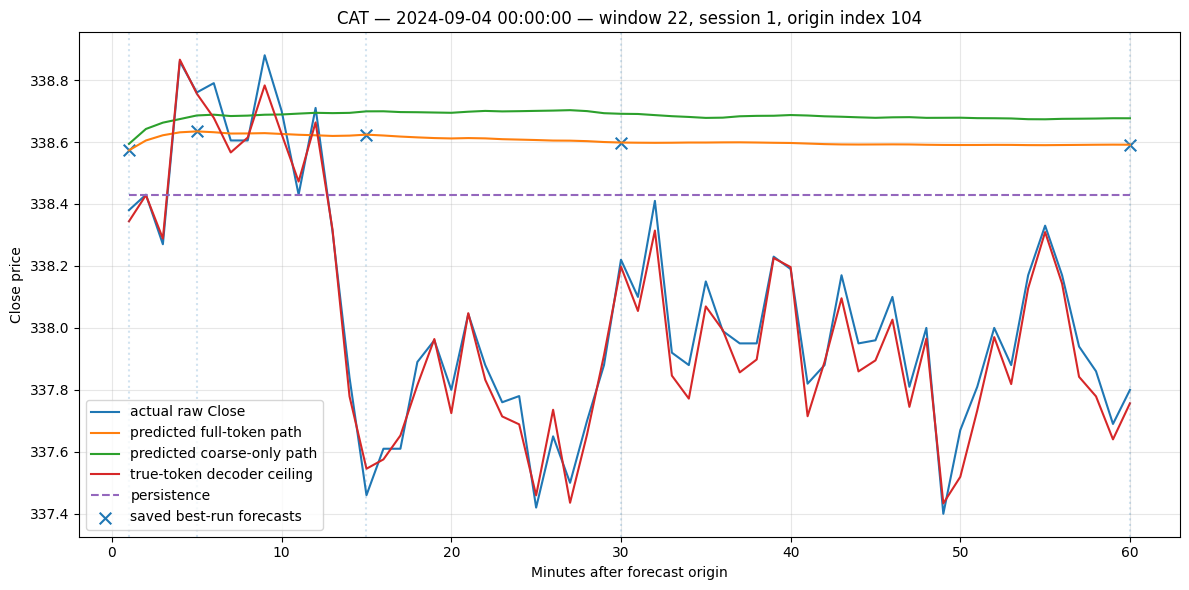

,window_index,asset_index,asset,date,sample_idx,origin_idx,origin_close,saved_vs_regenerated_eval_max_abs_difference
0,22,15,CAT,2024-09-04 00:00:00,1,104,338.429993,0.0


In [12]:
# Cell 12 — draw a new random asset/window price path on every call.

def plot_random_forecast_path() -> dict[str, Any]:
    random_generator = np.random.default_rng()
    window_index = int(
        random_generator.integers(0, len(validation_dataset))
    )
    asset_index = int(
        random_generator.integers(0, len(asset_cols))
    )

    batch = collate_cache_items(validation_dataset, [window_index])

    with torch.inference_mode():
        generated = diagnostic_model.generate(
            batch["context_tokens"].to(MODEL_DEVICE)
        )

    generated_tokens = generated.token_ids.detach().cpu().long()
    context_tokens_one = batch["context_tokens"][
        :, :, asset_index : asset_index + 1
    ].long()
    generated_tokens_one = generated_tokens[
        :, :, asset_index : asset_index + 1
    ]
    true_tokens_one = torch.stack(
        [
            batch["target_s1"][:, :, asset_index : asset_index + 1],
            batch["target_s2"][:, :, asset_index : asset_index + 1],
        ],
        dim=-1,
    ).long()

    mean_one = batch["context_mean"][:, asset_index : asset_index + 1]
    std_one = batch["context_std"][:, asset_index : asset_index + 1]

    predicted_full = tokenizer.decode_token_path(
        context_tokens_one,
        generated_tokens_one,
        mean=mean_one,
        std=std_one,
        series_batch_size=1,
    )
    predicted_coarse = tokenizer.decode_coarse_token_path(
        context_tokens_one,
        generated_tokens_one[..., 0],
        mean=mean_one,
        std=std_one,
        series_batch_size=1,
    )
    oracle_full = tokenizer.decode_token_path(
        context_tokens_one,
        true_tokens_one,
        mean=mean_one,
        std=std_one,
        series_batch_size=1,
    )

    raw_context, raw_future = raw_ohlcv_for_window(
        window_index,
        asset_indices=[asset_index],
    )

    actual_close = raw_future[:, 0, 3].numpy()
    origin_close = float(raw_context[-1, 0, 3])
    predicted_full_close = predicted_full[0, :, 0, 3].cpu().numpy()
    predicted_coarse_close = predicted_coarse[0, :, 0, 3].cpu().numpy()
    oracle_close = oracle_full[0, :, 0, 3].cpu().numpy()
    saved_eval_close = prediction_result["y_pred"][
        window_index, :, asset_index, 0
    ].cpu().numpy()

    future_minutes = np.arange(1, 61)
    plt.figure(figsize=(12, 6))
    plt.plot(future_minutes, actual_close, label="actual raw Close")
    plt.plot(
        future_minutes,
        predicted_full_close,
        label="predicted full-token path",
    )
    plt.plot(
        future_minutes,
        predicted_coarse_close,
        label="predicted coarse-only path",
    )
    plt.plot(
        future_minutes,
        oracle_close,
        label="true-token decoder ceiling",
    )
    plt.plot(
        future_minutes,
        np.full(60, origin_close),
        linestyle="--",
        label="persistence",
    )
    plt.scatter(
        evaluation_horizons,
        saved_eval_close,
        marker="x",
        s=70,
        label="saved best-run forecasts",
    )

    for horizon in evaluation_horizons:
        plt.axvline(horizon, linestyle=":", alpha=0.2)

    sample_idx = int(validation_cache["sample_idx"][window_index])
    origin_idx = int(validation_cache["origin_idx"][window_index])
    date = validation_cache["dates"][window_index]

    plt.xlabel("Minutes after forecast origin")
    plt.ylabel("Close price")
    plt.title(
        f"{asset_cols[asset_index]} — {date} — window {window_index}, "
        f"session {sample_idx}, origin index {origin_idx}"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    regenerated_eval = predicted_full_close[evaluation_indices]

    return {
        "window_index": window_index,
        "asset_index": asset_index,
        "asset": asset_cols[asset_index],
        "date": date,
        "sample_idx": sample_idx,
        "origin_idx": origin_idx,
        "origin_close": origin_close,
        "saved_vs_regenerated_eval_max_abs_difference": float(
            np.max(np.abs(saved_eval_close - regenerated_eval))
        ),
    }


random_forecast_details = plot_random_forecast_path()
display(pd.DataFrame([random_forecast_details]))

# Rerun this cell, or call plot_random_forecast_path(), for a new draw.


In [13]:
# Cell 13 — compact evidence table for the next decision.

best_graph_stats = graph_state_table.loc[
    graph_state_table["state"] == "best"
].iloc[0]
last_graph_stats = graph_state_table.loc[
    graph_state_table["state"] == "last"
].iloc[0]
initial_to_best = graph_movement_table.loc[
    graph_movement_table["comparison"] == "initial -> best"
].iloc[0]

predicted_full_row = decoded_variant_table.loc[
    decoded_variant_table["variant"] == "predicted full tokens"
].iloc[0]
predicted_coarse_row = decoded_variant_table.loc[
    decoded_variant_table["variant"] == "predicted coarse only"
].iloc[0]

summary_table = pd.DataFrame(
    [
        {
            "question": "Does forecasting loss reach the graph logits?",
            "diagnostic": free_static_graph_gradient_rms,
            "interpretation": "Off-diagonal s1-loss gradient RMS on the best graph logits.",
        },
        {
            "question": "Did the graph move from initialisation by the best epoch?",
            "diagnostic": float(initial_to_best["off_diagonal_logit_relative_l2_change"]),
            "interpretation": "Relative off-diagonal graph-logit L2 movement.",
        },
        {
            "question": "How concentrated is the best graph?",
            "diagnostic": float(best_graph_stats["mean_effective_neighbours"]),
            "interpretation": "Mean effective neighbours; the uniform non-self graph is 92.",
        },
        {
            "question": "Did graph concentration continue after the selected epoch?",
            "diagnostic": float(last_graph_stats["mean_effective_neighbours"]),
            "interpretation": "Last-checkpoint effective neighbours.",
        },
        {
            "question": "Does coarse-only decoding improve sampled five-horizon MAE?",
            "diagnostic": float(
                predicted_coarse_row["five_horizon_clg_mae"]
                / predicted_full_row["five_horizon_clg_mae"]
            ),
            "interpretation": "<1 favours coarse-only decoding on the diagnostic subset.",
        },
        {
            "question": "Does coarse-only decoding improve candle validity?",
            "diagnostic": float(
                predicted_coarse_row["invalid_candle_rate_percent"]
                - predicted_full_row["invalid_candle_rate_percent"]
            ),
            "interpretation": "Negative means fewer invalid candles than full-token decoding.",
        },
    ]
)

display(summary_table)
print("FREE-STATIC RUN DIAGNOSTIC NOTEBOOK COMPLETE")


,question,diagnostic,interpretation
0,Does forecasting loss reach the graph logits?,0.000001,Off-diagonal s1-loss gradient RMS on the best ...
1,Did the graph move from initialisation by the ...,2.893424,Relative off-diagonal graph-logit L2 movement.
2,How concentrated is the best graph?,91.721773,Mean effective neighbours; the uniform non-sel...
3,Did graph concentration continue after the sel...,50.700594,Last-checkpoint effective neighbours.
4,Does coarse-only decoding improve sampled five...,1.012728,<1 favours coarse-only decoding on the diagnos...
5,Does coarse-only decoding improve candle valid...,-16.527778,Negative means fewer invalid candles than full...


FREE-STATIC RUN DIAGNOSTIC NOTEBOOK COMPLETE
